# LRK10L ML model

## Setup

### Imports & installations

In [2]:
%load_ext autoreload
%autoreload 2

from lrk10l.evaluation import LOGOEvaluator
from lrk10l.pu import run_pu_bagging, PUFilterMixin

import pyhmmer
from pyhmmer.easel import MSAFile, Alphabet
from Bio import SeqIO
import esm
from tqdm.auto import tqdm
from joblib import Parallel, delayed
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import LeaveOneGroupOut, cross_val_score, StratifiedKFold
from sklearn.metrics import precision_score, recall_score, accuracy_score, average_precision_score, precision_recall_curve, log_loss, f1_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import hypergeom, friedmanchisquare, studentized_range
import scikit_posthocs as sp
import torch
from pathlib import Path
import os
import itertools
from itertools import combinations
import math
from functools import reduce
from collections import Counter

### Helper functions

In [3]:
def clean_gene_id(gene_id: str) -> str:
    return gene_id.split('|')[0]

def get_scale_pos_weight(y):
    return (y == 0).sum() / (y == 1).sum()

### Load HMMs

In [4]:
os.makedirs('../data/hmms', exist_ok=True)

!wget -O ../data/hmms/PF00069.hmm.gz "https://www.ebi.ac.uk/interpro/wwwapi/entry/pfam/PF00069?annotation=hmm"
!gunzip -f ../data/hmms/PF00069.hmm.gz
!file ../data/hmms/PF00069.hmm

!wget -O ../data/hmms/PF07714.hmm.gz "https://www.ebi.ac.uk/interpro/wwwapi/entry/pfam/PF07714?annotation=hmm"
!gunzip -f ../data/hmms/PF07714.hmm.gz
!file ../data/hmms/PF07714.hmm

--2026-08-23 00:09:00--  https://www.ebi.ac.uk/interpro/wwwapi/entry/pfam/PF00069?annotation=hmm
Resolving www.ebi.ac.uk (www.ebi.ac.uk)... 193.62.193.80
Connecting to www.ebi.ac.uk (www.ebi.ac.uk)|193.62.193.80|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 25382 (25K) [application/gzip]
Saving to: ‘../data/hmms/PF00069.hmm.gz’

../data/hmms/PF0006 100%[===================>]  24.79K  --.-KB/s    in 0.08s   

2026-08-23 00:09:01 (300 KB/s) - ‘../data/hmms/PF00069.hmm.gz’ saved [25382/25382]

../data/hmms/PF00069.hmm: ASCII text
--2026-08-23 00:09:01--  https://www.ebi.ac.uk/interpro/wwwapi/entry/pfam/PF07714?annotation=hmm
Resolving www.ebi.ac.uk (www.ebi.ac.uk)... 193.62.193.80
Connecting to www.ebi.ac.uk (www.ebi.ac.uk)|193.62.193.80|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24895 (24K) [application/gzip]
Saving to: ‘../data/hmms/PF07714.hmm.gz’

../data/hmms/PF0771 100%[===================>]  24.31K  --.-KB/s    in 0.09s   


In [5]:
def read_hmms(hmm_dir: Path) -> list[pyhmmer.plan7.HMM]:
    hmms = []
    for hmm_file in hmm_dir.glob('*.hmm'):
        with pyhmmer.plan7.HMMFile(hmm_file) as f:
            hmms.append(f.read())
    return hmms

def search_proteome_for_kinases(proteome_path: Path, hmms: list[pyhmmer.plan7.HMM]) -> set[str]:
    with pyhmmer.easel.SequenceFile(proteome_path, digital=True) as f:
        sequences = f.read_block()

    unique_names = set()
    for hmm in hmms:
        try:
            pipeline = pyhmmer.plan7.Pipeline(hmm.alphabet, bit_cutoffs='gathering')
            hits = pipeline.search_hmm(hmm, sequences)
        except pyhmmer.errors.MissingCutoffs:
            pipeline = pyhmmer.plan7.Pipeline(hmm.alphabet, E=0.001)
            hits = pipeline.search_hmm(hmm, sequences)
        except pyhmmer.errors.AlphabetMismatch:
            print(f'{proteome_path} is not protein, skipped.')
            continue

        for hit in hits.included:
            unique_names.add(clean_gene_id(hit.name))

    return unique_names

hmm_dir = Path('../data/hmms')
hmms = read_hmms(hmm_dir)
print(f'{len(hmms)} HMM(s) loaded')

2 HMM(s) loaded


## Load data

### Load sequences

In [6]:
records = []
record_species = {}

for fname in os.listdir('../data/sequences'):
    species_name = os.path.splitext(fname)[0]

    filepath = os.path.join('../data/sequences', fname)
    with open(filepath) as handle:
        for rec in SeqIO.parse(handle, 'fasta'):
            rec.id = clean_gene_id(rec.id)
            rec.description = ''
            rec.seq = rec.seq.rstrip('*')
            records.append(rec)
            record_species[rec.id] = species_name

print(len(records), 'FASTA records')
print(len(set(record_species.values())), 'unique species')

249635 FASTA records
7 unique species


### Load LRK10L gene IDs

In [7]:
with open('../data/list.txt') as f:
    gene_ids = f.read().strip().split('\n')
gene_ids = set(gene_ids)

print(len(gene_ids), 'LRK10L gene IDs')

367 LRK10L gene IDs


### Check LRK10Ls missing from records

In [8]:
missing = gene_ids - set(rec.id for rec in records)
print(f'{len(missing)} LRK10L gene IDs not found in FASTA records')
if missing:
    print(list(missing)[:10])

0 LRK10L gene IDs not found in FASTA records


## Length filtering

Sequences <250aa cannot be kinases, yet kinase filtering still misses some.

In [9]:
MIN_SEQUENCE_LENGTH = 250
n_records_before = len(records)
records = [rec for rec in records if len(rec.seq) >= MIN_SEQUENCE_LENGTH]
record_species = {rec.id: record_species[rec.id] for rec in records}

print(f'Dropped {n_records_before - len(records)} sequences shorter than {MIN_SEQUENCE_LENGTH} aa')
print(f'{len(records)} FASTA records remaining')

Dropped 101983 sequences shorter than 250 aa
147652 FASTA records remaining


## Kinase filtering

### Filter all sequences

In [10]:
pkinase_hits = set()

files = os.listdir('../data/sequences')
for fname in tqdm(files, desc='Scanning proteomes'):
    filepath = Path('../data/sequences') / fname
    hits = search_proteome_for_kinases(filepath, hmms)
    print(f'{fname}: {len(hits)} kinase hits')
    pkinase_hits.update(hits)

print(f'{len(pkinase_hits)} total proteins with Pkinase hit across all species')

Scanning proteomes:   0%|          | 0/7 [00:00<?, ?it/s]

Slycopersicum_796_ITAG5.0.protein_primaryTranscriptOnly.fa: 1014 kinase hits
Athaliana_447_Araport11.protein_primaryTranscriptOnly.fa: 1027 kinase hits
Vvinifera_457_v2.1.protein_primaryTranscriptOnly.fa: 1350 kinase hits
Fvesca_226_v1.1.protein_primaryTranscriptOnly.fa: 963 kinase hits
Osativa_204_v7.0.protein_primaryTranscriptOnly.fa: 1473 kinase hits
Pvulgaris_442_v2.1.protein_primaryTranscriptOnly.fa: 1245 kinase hits
Gmax_189_protein_primaryTranscriptOnly.fa: 2335 kinase hits
9407 total proteins with Pkinase hit across all species


### Check kinase filtering results

In [11]:
missing_pkinase = gene_ids - pkinase_hits
print(f'{len(missing_pkinase)} known LRK10L genes have NO Pkinase domain hit')
if missing_pkinase:
    print(list(missing_pkinase))

2 known LRK10L genes have NO Pkinase domain hit
['Solyc12T001479.1', 'PRAM_26255.1.p1']


### Drop non-kinases from records

In [12]:
records = [rec for rec in records if rec.id in pkinase_hits]
labels = {rec.id: (1 if rec.id in gene_ids else 0) for rec in records}
print(f'{len(records)} proteins retained after Pkinase filter')

8945 proteins retained after Pkinase filter


## Leave-one-group-out

In [13]:
logo = LeaveOneGroupOut()

## Dedup

Remove duplicates within each species using cd-hit

Aug 16: This doesn't help much.

In [14]:
RUN_DEDUP = True  #@param {type:"boolean"}

### Cluster duplicates

In [15]:
if RUN_DEDUP:
    def check_redundancy(species_name, records, record_species, labels, out_dir='../intermediate/cdhit', c=0.90, n=5):
        pos_records = [
            rec for rec in records
            if record_species[rec.id] == species_name and labels[rec.id] == 1
        ]
        if len(pos_records) < 2:
            return {'species': species_name, 'n_input': len(pos_records), 'n_clusters': None, 'redundancy': None}

        os.makedirs(out_dir, exist_ok=True)
        safe_name = species_name.replace(' ', '_')
        fasta_path = f'{out_dir}/{safe_name}_positives.fasta'
        out_path = f'{out_dir}/{safe_name}'

        SeqIO.write(pos_records, fasta_path, 'fasta')

        !cd-hit -i {fasta_path} -o {out_path} -c {c} -n {n} -d 0 -aL 0.8 -aS 0.8 > /dev/null

        n_clusters = sum(1 for _ in SeqIO.parse(out_path, 'fasta'))
        redundancy = 1 - n_clusters / len(pos_records)
        return {
            'species': species_name,
            'n_input': len(pos_records),
            'n_clusters': n_clusters,
            'redundancy': redundancy,
        }

    results = []
    for species_name in sorted(set(record_species.values())):
        res = check_redundancy(species_name, records, record_species, labels)
        results.append(res)
    redundancy_df = pd.DataFrame(results).sort_values('redundancy', ascending=False)
    display(redundancy_df)

,species,n_input,n_clusters,redundancy
6,Vvinifera_457_v2.1.protein_primaryTranscriptOnly,104,73,0.298077
2,Gmax_189_protein_primaryTranscriptOnly,90,76,0.155556
4,Pvulgaris_442_v2.1.protein_primaryTranscriptOnly,73,68,0.068493
3,Osativa_204_v7.0.protein_primaryTranscriptOnly,52,51,0.019231
0,Athaliana_447_Araport11.protein_primaryTranscr...,13,13,0.000000
1,Fvesca_226_v1.1.protein_primaryTranscriptOnly,10,10,0.000000
5,Slycopersicum_796_ITAG5.0.protein_primaryTrans...,17,17,0.000000


### Parse cd-hit output

In [16]:
if RUN_DEDUP:
    def clusters_to_dataframe(clstr_path, species_name):
        """Parse a .clstr file into a DataFrame."""
        clusters = []
        current = None
        with open(clstr_path) as f:
            for line in f:
                line = line.strip()
                if line.startswith('>Cluster'):
                    if current is not None:
                        clusters.append(current)
                    current = []
                else:
                    idx, rest = line.split('\t')
                    length = int(rest.split(',')[0].strip().rstrip('aa'))
                    seq_id = rest.split('>')[1].split('...')[0]
                    is_rep = '*' in rest
                    identity = None if is_rep else rest.split('at')[-1].strip()
                    current.append({
                        'seq_id': seq_id,
                        'length': length,
                        'is_representative': is_rep,
                        'identity_to_rep': identity,
                    })
            if current is not None:
                clusters.append(current)
        rows = []
        for i, cluster in enumerate(clusters):
            for m in cluster:
                rows.append({
                    'species': species_name,
                    'cluster_id': i,
                    'cluster_size': len(cluster),
                    **m,
                })
        return pd.DataFrame(rows)

    all_cluster_dfs = []
    for species_name in sorted(set(record_species.values())):
        safe_name = species_name.replace(' ', '_')
        clstr_path = f'../intermediate/cdhit/{safe_name}.clstr'
        if not os.path.exists(clstr_path):
            continue
        df = clusters_to_dataframe(clstr_path, species_name)
        all_cluster_dfs.append(df)
    all_clusters_df = pd.concat(all_cluster_dfs, ignore_index=True)
    redundant_df = all_clusters_df[all_clusters_df['cluster_size'] > 1].sort_values(
        ['species', 'cluster_size', 'cluster_id', 'is_representative'], ascending=[True, False, True, False]
    )

### Drop duplicates

In [17]:
if RUN_DEDUP:
    ids_to_drop = set(
        all_clusters_df.loc[
            (~all_clusters_df['is_representative']) & (all_clusters_df['cluster_size'] > 1),
            'seq_id'
        ]
    )
    print(f'{len(ids_to_drop)} sequences to drop as redundant')

    records_deduped = [rec for rec in records if rec.id not in ids_to_drop]
    print(f'{len(records_deduped)} records remaining after dropping redundant sequences')
else:
    records_deduped = records
    print(f'{len(records_deduped)} records (dedup skipped)')

labels_deduped = {rec.id: (1 if rec.id in gene_ids else 0) for rec in records_deduped}
y_deduped = np.array([labels[rec.id] for rec in records_deduped])
groups_deduped = np.array([record_species[rec.id] for rec in records_deduped])

51 sequences to drop as redundant
8894 records remaining after dropping redundant sequences


## HMM baseline

Three-way outer split by species: use N-2 species to build the HMM, one validation species to select the e-value threshold, and one test species for final metrics.

In [18]:
LOAD_HMM_RESULTS = True  #@param {"type": "boolean"}

### Align, build, scan

In [19]:
hmm_baseline_dir = '../intermediate/hmm_baseline'
hmm_results_name = '../saves/hmm_results_df.csv'
os.makedirs(hmm_baseline_dir, exist_ok=True)

In [20]:
if not LOAD_HMM_RESULTS:
    hmm_df = pd.DataFrame({
        'record': records_deduped,
        'species': [record_species[rec.id] for rec in records_deduped],
        'label': [labels_deduped[rec.id] for rec in records_deduped],
    })

    # full lookup used only for the test split
    hmm_df_full = pd.DataFrame({
        'record': records,
        'species': [record_species[rec.id] for rec in records],
        'label': [labels[rec.id] for rec in records],
    })

    hmm_results = []
    all_species = sorted(hmm_df['species'].unique())

    def get_validation_species(all_species, test_species):
        others = [species for species in all_species if species != test_species]
        index = all_species.index(test_species) % len(others)
        return others[index]

    pbar = tqdm(all_species, desc='Evaluate HMM')
    for test_species in pbar:
        validation_species = get_validation_species(all_species, test_species)
        train_species = [
            species for species in all_species
            if species not in {validation_species, test_species}
        ]

        train_df = hmm_df[hmm_df['species'].isin(train_species)]
        validation_df = hmm_df[hmm_df['species'] == validation_species]
        test_df = hmm_df_full[hmm_df_full['species'] == test_species]

        species_pretty = test_species.split('_')[0]
        validation_species_pretty = validation_species.split('_')[0]
        pbar.set_postfix_str(species_pretty)

        train_fa_name = f'{hmm_baseline_dir}/{species_pretty}_train.fasta'
        validation_fa_name = f'{hmm_baseline_dir}/{species_pretty}_validation.fasta'
        test_fa_name = f'{hmm_baseline_dir}/{species_pretty}_test.fasta'
        aligned_fa_name = f'{hmm_baseline_dir}/{species_pretty}_train_aligned.fasta'

        SeqIO.write(
            list(train_df[train_df['label'] == 1]['record']),
            train_fa_name,
            'fasta',
        )
        SeqIO.write(list(validation_df['record']), validation_fa_name, 'fasta')
        SeqIO.write(list(test_df['record']), test_fa_name, 'fasta')

        !muscle -align {train_fa_name} -output {aligned_fa_name} -quiet

        alphabet = pyhmmer.easel.Alphabet.amino()
        with pyhmmer.easel.MSAFile(aligned_fa_name, digital=True, alphabet=alphabet) as msa_file:
            msa = msa_file.read()
            msa.name = f'LRK10L_{species_pretty}'

            builder = pyhmmer.plan7.Builder(alphabet)
            background = pyhmmer.plan7.Background(alphabet)
            hmm, _, _ = builder.build_msa(msa, background)

        for split_name, split_species, split_fa_name, split_df, split_labels in [
            ('validation', validation_species, validation_fa_name, validation_df, labels_deduped),
            ('test', test_species, test_fa_name, test_df, labels),
        ]:
            with pyhmmer.easel.SequenceFile(split_fa_name, digital=True, alphabet=alphabet) as seq_file:
                split_seqs = list(seq_file)

            for seq, hits in zip(split_seqs, pyhmmer.hmmscan(split_seqs, [hmm], E=1e-4)):
                best_hit = min(hits, key=lambda h: h.evalue, default=None)
                hmm_results.append({
                    'outer_test_species': test_species,
                    'validation_species': validation_species,
                    'species': split_species,
                    'split': split_name,
                    'record_id': seq.name,
                    'pred_label': 1 if best_hit is not None else 0,
                    'true_label': split_labels[seq.name],
                    'evalue': best_hit.evalue if best_hit is not None else None,
                })

    hmm_results_df = pd.DataFrame(hmm_results)
    hmm_results_df.to_csv(hmm_results_name, index=False)
else:
    hmm_results_df = pd.read_csv(hmm_results_name)

### Visualize log e-values by label

,count,mean,std,min,25%,50%,75%,max
true_label,,,,,,,,
0,17030.0,1.648742e-08,9.505046e-07,0.0,4.275000e-101,1.354077e-77,1.087971e-36,8.384228e-05
1,667.0,5.368517e-30,1.322094e-28,0.0,3.386183e-203,1.305629e-178,1.313547e-156,3.410490e-27


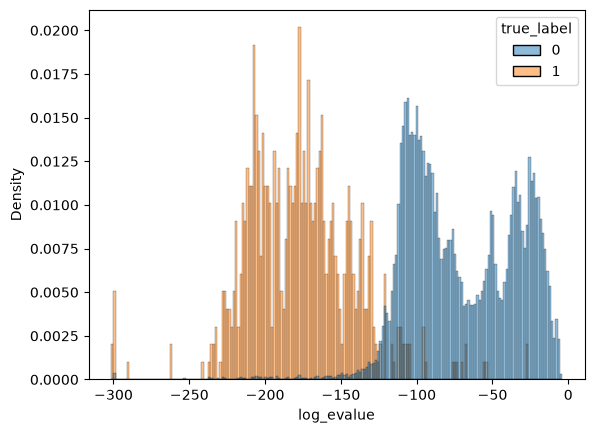

In [21]:
hmm_results_df['log_evalue'] = np.log10(hmm_results_df['evalue'].replace(0, 1e-300))

sns.histplot(data=hmm_results_df, x='log_evalue', hue='true_label', bins=200, stat='density', common_norm=False)
hmm_results_df.groupby('true_label')['evalue'].describe()

### Generate metrics

In [22]:
hmm_results_df['evalue_filled'] = hmm_results_df['evalue'].fillna(1e10)


def best_f1_evalue_threshold(y_true, evalues):
    candidates = np.unique(evalues)
    best_threshold, best_f1 = float(candidates[0]), -1.0
    for threshold in candidates:
        f1 = f1_score(y_true, evalues <= threshold, zero_division=0)
        if f1 > best_f1:
            best_threshold, best_f1 = float(threshold), float(f1)
    return best_threshold, best_f1


all_test_species = sorted(hmm_results_df['outer_test_species'].unique())
hmm_fold_rows = []
hmm_fold_preds = {}

for test_species in all_test_species:
    fold_rows = hmm_results_df[hmm_results_df['outer_test_species'] == test_species]
    validation_rows = fold_rows[fold_rows['split'] == 'validation']
    test_rows = fold_rows[fold_rows['split'] == 'test']

    validation_threshold, validation_f1 = best_f1_evalue_threshold(
        validation_rows['true_label'].to_numpy(),
        validation_rows['evalue_filled'].to_numpy(),
    )
    test_y = test_rows['true_label'].to_numpy()
    test_evalues = test_rows['evalue_filled'].to_numpy()
    test_pred = test_evalues <= validation_threshold

    hmm_results_df.loc[fold_rows.index, 'fold_threshold'] = validation_threshold
    hmm_results_df.loc[fold_rows.index, 'pred_label'] = (
        hmm_results_df.loc[fold_rows.index, 'evalue_filled'] <= validation_threshold
    ).astype(int)
    hmm_fold_preds[test_species] = {
        'y_true': test_y,
        'preds': -test_evalues,
    }

    hmm_fold_rows.append({
        'species': test_species.split('_')[0],
        'validation_species': validation_rows['species'].iloc[0].split('_')[0],
        'threshold': validation_threshold,
        'val_f1_at_threshold': validation_f1,
        'test_pr_auc': average_precision_score(test_y, -test_evalues),
        'test_precision': precision_score(test_y, test_pred, zero_division=0),
        'test_recall': recall_score(test_y, test_pred, zero_division=0),
        'test_accuracy': accuracy_score(test_y, test_pred),
        'n_pos': int(test_y.sum()),
        'found': int(((test_y == 1) & test_pred).sum()),
        'false_positives': int(((test_y == 0) & test_pred).sum()),
    })

hmm_fold_results = pd.DataFrame(hmm_fold_rows)

In [23]:
hmm_fold_results = hmm_fold_results.assign(
    precision=hmm_fold_results['test_precision'],
    recall=hmm_fold_results['test_recall'],
    accuracy=hmm_fold_results['test_accuracy'],
)

hmm_fold_results[[
    'species', 'validation_species', 'threshold', 'val_f1_at_threshold',
    'test_pr_auc', 'test_precision', 'test_recall', 'test_accuracy',
    'n_pos', 'found', 'false_positives'
]]

,species,validation_species,threshold,val_f1_at_threshold,test_pr_auc,test_precision,test_recall,test_accuracy,n_pos,found,false_positives
0,Athaliana,Fvesca,1.126523e-121,0.454545,0.925902,0.406250,1.000000,0.981281,13,13,19
1,Fvesca,Gmax,1.235060e-140,0.869565,0.360404,0.250000,0.400000,0.980519,10,4,12
2,Gmax,Osativa,1.237162e-135,0.895238,0.920758,0.876404,0.866667,0.989583,90,78,11
3,Osativa,Pvulgaris,5.732082e-140,0.948905,0.848862,0.860000,0.826923,0.988850,52,43,7
4,Pvulgaris,Slycopersicum,1.248097e-207,0.486486,0.957323,1.000000,0.246575,0.955029,73,18,0
5,Slycopersicum,Vvinifera,1.054984e-151,0.787879,0.337653,0.304348,0.823529,0.963466,17,14,32
6,Vvinifera,Athaliana,9.092581e-168,0.916667,0.680681,0.746988,0.596154,0.946701,104,62,21


## [ESM] Build dataset

In [24]:
LOAD_ESM = True  #@param {type:"boolean"}

### Load ESM model

In [25]:
esm_model, alphabet = esm.pretrained.esm2_t30_150M_UR50D()
batch_converter = alphabet.get_batch_converter()
esm_model.eval()

device = torch.device(
    'mps' if torch.backends.mps.is_available()
    else 'cuda' if torch.cuda.is_available()
    else 'cpu'
)
esm_model = esm_model.to(device)

### Generate or load embeddings

In [26]:
def esm_embed_records(records, esm_model, alphabet, batch_converter, device,
                           batch_size=8, max_len=1022):
    esm_model.eval()
    embeddings = {}

    print(f"Using device: {device}")

    # ESM has a length limit; truncate very long sequences
    data = [(rec.id, str(rec.seq)[:max_len]) for rec in records]
    data = sorted(data, key=lambda x: len(x[1]))

    for i in tqdm(range(0, len(data), batch_size), desc="Embedding batches"):
        batch = data[i:i+batch_size]
        labels, strs, tokens = batch_converter(batch)
        tokens = tokens.to(device)

        with torch.no_grad():
            out = esm_model(tokens, repr_layers=[esm_model.num_layers])
            reps = out['representations'][esm_model.num_layers]  # (batch, seq_len, embed_dim)

        for j, (label, seq) in enumerate(batch):
            # mean-pool over real residues, skipping BOS/EOS/padding tokens
            seq_len = len(seq)
            emb = reps[j, 1:seq_len+1].mean(0)  # +1 to skip BOS token
            embeddings[label] = emb.cpu().numpy()

    return embeddings

ESM_MODEL_NAME = 'esm2_t30_150M_UR50D'
ESM_SAVE_PATH = Path(f'../saves/{ESM_MODEL_NAME}_embeddings.npz')

def save_embeddings(embeddings: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    ids = np.array(list(embeddings.keys()))
    vecs = np.stack([embeddings[i] for i in ids])
    np.savez_compressed(path, ids=ids, embeddings=vecs)
    print(f'Saved {len(ids)} embeddings to {path}')

def load_embeddings(path: Path) -> dict:
    data = np.load(path, allow_pickle=False)
    ids, vecs = data['ids'], data['embeddings']
    return {i: v for i, v in zip(ids, vecs)}

all_ids = set(rec.id for rec in records)

if LOAD_ESM and ESM_SAVE_PATH.exists():
    embeddings_full_esm = load_embeddings(ESM_SAVE_PATH)
    missing_ids = all_ids - set(embeddings_full_esm.keys())

    if missing_ids:
        print(f'{len(missing_ids)} records missing from saved embeddings, generating those')
        missing_records = [rec for rec in records if rec.id in missing_ids]
        new_embeddings = esm_embed_records(missing_records, esm_model, alphabet, batch_converter, device)
        embeddings_full_esm.update(new_embeddings)
        save_embeddings(embeddings_full_esm, ESM_SAVE_PATH)  # persist the merged set
    else:
        print(f'Loaded {len(embeddings_full_esm)} embeddings from {ESM_SAVE_PATH}, all records covered')
else:
    embeddings_full_esm = esm_embed_records(records, esm_model, alphabet, batch_converter, device)
    save_embeddings(embeddings_full_esm, ESM_SAVE_PATH)

X_deduped_esm = pd.DataFrame(
    [embeddings_full_esm[rec.id] for rec in records_deduped],
    index=[rec.id for rec in records_deduped]
)
print(X_deduped_esm.shape)

Loaded 9407 embeddings from ../saves/esm2_t30_150M_UR50D_embeddings.npz, all records covered
(8894, 640)


### Keep embeddings for full data

In [27]:
# Save copy of full ESM feature matrix
X_esm = pd.DataFrame(
    [embeddings_full_esm[rec.id] for rec in records],
    index=[rec.id for rec in records]
)

y = np.array([labels[rec.id] for rec in records])
groups = np.array([record_species[rec.id] for rec in records])

print(X_esm.shape, 'full post-kinase-filter pre-dedup ESM dataset')

(8945, 640) full post-kinase-filter pre-dedup ESM dataset


## [k-mer] Build dataset

### Build k-mer vectors

In [28]:
AMINO_ACIDS = 'ACDEFGHIKLMNPQRSTVWY'
K = 2

all_kmers = [''.join(p) for p in itertools.product(AMINO_ACIDS, repeat=K)]
kmer_index = {kmer: i for i, kmer in enumerate(all_kmers)}
print(f'{len(all_kmers)} possible {K}-mers')

def kmer_freq_vector(seq, k, kmer_index):
    seq = str(seq).upper()
    vec = np.zeros(len(kmer_index))
    count = 0
    for i in range(len(seq) - k + 1):
        kmer = seq[i:i+k]
        if kmer in kmer_index:  # skip ambiguous
            vec[kmer_index[kmer]] += 1
            count += 1
    if count > 0:
        vec /= count  # normalize
    return vec

X_deduped_kmer = pd.DataFrame(
    [kmer_freq_vector(rec.seq, K, kmer_index) for rec in records_deduped],
    columns=all_kmers,
    index=[rec.id for rec in records_deduped]
)
print(X_deduped_kmer.shape)
display(X_deduped_kmer.head())

400 possible 2-mers
(8894, 400)


,AA,AC,AD,AE,AF,AG,AH,AI,AK,AL,...,YM,YN,YP,YQ,YR,YS,YT,YV,YW,YY
PRAM_24043.1.p1,0.001820,0.000910,0.000000,0.001820,0.000910,0.000000,0.000910,0.002730,0.000910,0.010919,...,0.000910,0.00182,0.000910,0.000000,0.000000,0.001820,0.000000,0.000910,0.0,0.000910
PRAM_25906.1.p1,0.007072,0.000000,0.000000,0.002829,0.000000,0.002829,0.000000,0.004243,0.007072,0.002829,...,0.001414,0.00000,0.002829,0.000000,0.002829,0.002829,0.002829,0.001414,0.0,0.001414
PRAM_26245.1.p1,0.003049,0.000000,0.000000,0.000000,0.001524,0.003049,0.000000,0.006098,0.000000,0.003049,...,0.000000,0.00000,0.001524,0.003049,0.001524,0.006098,0.001524,0.003049,0.0,0.000000
PRAM_26268.1.p1,0.004890,0.000000,0.000000,0.004890,0.002445,0.002445,0.002445,0.004890,0.007335,0.007335,...,0.002445,0.00000,0.000000,0.002445,0.004890,0.004890,0.007335,0.002445,0.0,0.002445
PRAM_26328.1.p1,0.006126,0.001531,0.003063,0.003063,0.003063,0.003063,0.000000,0.003063,0.003063,0.006126,...,0.001531,0.00000,0.001531,0.001531,0.001531,0.003063,0.001531,0.003063,0.0,0.000000


### Build k-mer vectors for full data

This is needed for some analysis requiring un-deduped data.

In [29]:
X_kmer = pd.DataFrame(
    [kmer_freq_vector(rec.seq, K, kmer_index) for rec in records],
    columns=all_kmers,
    index=[rec.id for rec in records]
)
y = np.array([labels[rec.id] for rec in records])
groups = np.array([record_species[rec.id] for rec in records])

print(X_kmer.shape, 'full post-kinase-filter pre-dedup dataset')

(8945, 400) full post-kinase-filter pre-dedup dataset


## Check dataset

In [30]:
zero_rows = (X_deduped_kmer.sum(axis=1) == 0).sum()
print(f'{zero_rows} sequences with no valid k-mers extracted')

print(len(groups), 'group labels built')
print(len(set(groups)), 'unique species in groups')

pos_species = pd.Series([record_species[rec.id] for rec in records_deduped if labels_deduped[rec.id] == 1])
print(pos_species.value_counts())

0 sequences with no valid k-mers extracted
8945 group labels built
7 unique species in groups
Gmax_189_protein_primaryTranscriptOnly                     76
Vvinifera_457_v2.1.protein_primaryTranscriptOnly           73
Pvulgaris_442_v2.1.protein_primaryTranscriptOnly           68
Osativa_204_v7.0.protein_primaryTranscriptOnly             51
Slycopersicum_796_ITAG5.0.protein_primaryTranscriptOnly    17
Athaliana_447_Araport11.protein_primaryTranscriptOnly      13
Fvesca_226_v1.1.protein_primaryTranscriptOnly              10
Name: count, dtype: int64


## Positive-unlabeled bagging

https://academic.oup.com/bib/article/23/1/bbab461/6415313

In [31]:
RUN_PU = True  #@param {type: "boolean"}

### PU global diagnostic

In [32]:
if RUN_PU:
    N_ITER = 100
    NEG_SAMPLE_RATIO = 3

    pos_idx_all = np.where(y_deduped == 1)[0]
    neg_idx_all = np.where(y_deduped == 0)[0]

    pu_scores_diag, n_oob_diag = run_pu_bagging(
        X_deduped_kmer, y_deduped, pos_idx_all, neg_idx_all,
        n_iter=N_ITER, neg_sample_ratio=NEG_SAMPLE_RATIO, seed=2026,
    )

    pu_df_diagnostic = pd.DataFrame({
        'id': X_deduped_kmer.index[neg_idx_all],
        'species': groups_deduped[neg_idx_all],
        'pu_score': pu_scores_diag,
        'n_oob': n_oob_diag,
    }).sort_values('pu_score', ascending=False)
    display(pu_df_diagnostic.groupby('species').head(10))

,id,species,pu_score,n_oob
823,Solyc11T000233.1,Slycopersicum_796_ITAG5.0.protein_primaryTrans...,0.968773,89.0
822,Solyc11T000232.1,Slycopersicum_796_ITAG5.0.protein_primaryTrans...,0.966601,90.0
14,Solyc01T000275.1,Slycopersicum_796_ITAG5.0.protein_primaryTrans...,0.912118,90.0
2098,VIT_201s0011g03980.1,Vvinifera_457_v2.1.protein_primaryTranscriptOnly,0.887079,90.0
2179,VIT_216s0013g01386.1,Vvinifera_457_v2.1.protein_primaryTranscriptOnly,0.875791,94.0
...,...,...,...,...
5836,Phvul.008G027100.1.p,Pvulgaris_442_v2.1.protein_primaryTranscriptOnly,0.458574,93.0
1677,AT3G53840.1,Athaliana_447_Araport11.protein_primaryTranscr...,0.421475,89.0
1400,AT1G16110.1,Athaliana_447_Araport11.protein_primaryTranscr...,0.414716,89.0
1337,AT1G21210.1,Athaliana_447_Araport11.protein_primaryTranscr...,0.402212,90.0


### PU score distribution

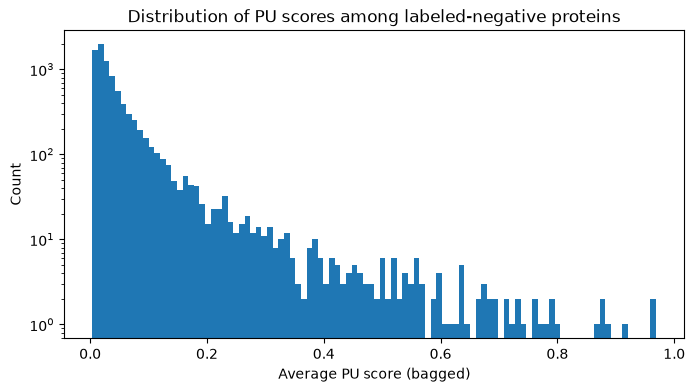

,count,mean,std,min,25%,50%,75%,max
species,,,,,,,,
Athaliana_447_Araport11.protein_primaryTranscriptOnly,1002.0,0.043418,0.065814,0.004942,0.013659,0.023626,0.046744,0.731579
Fvesca_226_v1.1.protein_primaryTranscriptOnly,914.0,0.053498,0.080294,0.004331,0.014811,0.026826,0.054284,0.792055
Gmax_189_protein_primaryTranscriptOnly,2118.0,0.052770,0.070995,0.004873,0.016550,0.029572,0.058495,0.786718
Osativa_204_v7.0.protein_primaryTranscriptOnly,1383.0,0.053009,0.079765,0.004373,0.014565,0.026630,0.054459,0.689875
Pvulgaris_442_v2.1.protein_primaryTranscriptOnly,1150.0,0.056626,0.079601,0.004253,0.016709,0.028936,0.058632,0.729919
Slycopersicum_796_ITAG5.0.protein_primaryTranscriptOnly,941.0,0.051782,0.090206,0.004651,0.015148,0.026055,0.053533,0.968773
Vvinifera_457_v2.1.protein_primaryTranscriptOnly,1078.0,0.066620,0.115186,0.003743,0.015994,0.030132,0.063143,0.887079


,count,mean,std,min,25%,50%,75%,max
species,,,,,,,,
Athaliana_447_Araport11.protein_primaryTranscriptOnly,1002.0,89.308383,3.086775,78.0,87.0,89.0,91.0,99.0
Fvesca_226_v1.1.protein_primaryTranscriptOnly,914.0,89.060175,3.083662,79.0,87.0,89.0,91.0,97.0
Gmax_189_protein_primaryTranscriptOnly,2118.0,89.261568,3.040049,79.0,87.0,89.0,91.0,97.0
Osativa_204_v7.0.protein_primaryTranscriptOnly,1383.0,89.139552,3.100122,79.0,87.0,89.0,91.0,98.0
Pvulgaris_442_v2.1.protein_primaryTranscriptOnly,1150.0,89.276522,3.015779,79.0,87.0,89.0,91.0,97.0
Slycopersicum_796_ITAG5.0.protein_primaryTranscriptOnly,941.0,89.471838,3.031133,79.0,88.0,90.0,91.0,97.0
Vvinifera_457_v2.1.protein_primaryTranscriptOnly,1078.0,89.160482,3.032360,80.0,87.0,89.0,91.0,98.0


In [33]:
if RUN_PU:
    plt.figure(figsize=(8, 4))
    plt.hist(pu_df_diagnostic['pu_score'], bins=100)
    plt.xlabel('Average PU score (bagged)')
    plt.ylabel('Count')
    plt.yscale('log')
    plt.title('Distribution of PU scores among labeled-negative proteins')
    plt.show()

    display(pu_df_diagnostic.groupby('species')['pu_score'].describe())
    display(pu_df_diagnostic.groupby('species')['n_oob'].describe())

### Do HMM FPs match PU-flagged candidates?

Ensure this is updated to match HMM results.

In [34]:
if RUN_PU:
    pu_candidates = set(pu_df_diagnostic.loc[pu_df_diagnostic['pu_score'] >= 0.80, 'id'])

    hmm_false_positive_ids = set("""
LOC_Os01g26210.1
LOC_Os02g42110.1
LOC_Os02g42160.1
LOC_Os02g42190.1
LOC_Os04g03830.1
LOC_Os04g29580.1
LOC_Os10g09620.1
VIT_200s0294g00020.1
VIT_200s0294g00080.1
VIT_200s0424g00020.1
VIT_201s0011g03960.1
VIT_201s0011g03980.1
VIT_201s0026g01420.1
VIT_208s0007g00960.1
VIT_208s0007g04350.1
VIT_213s0019g02300.1
VIT_214s0006g02600.2
VIT_216s0013g01198.1
VIT_216s0013g01235.1
VIT_216s0013g01386.1
VIT_217s0000g03340.1
Solyc01T000275.1
Solyc05T000170.1
Solyc11T000232.1
Solyc11T000233.1
Glyma04g13054.1
Glyma18g53186.1
mrna02191.1-v1.0-hybrid
mrna11412.1-v1.0-hybrid
Phvul.001G076300.1.p
Phvul.007G031300.1.p
    """.strip().split('\n'))
    overlap = pu_candidates & hmm_false_positive_ids
    print(f'{len(overlap)} of {len(pu_candidates)} PU candidates overlap with HMM false positives')
    print(overlap)

7 of 8 PU candidates overlap with HMM false positives
{'VIT_216s0013g01386.1', 'Solyc11T000233.1', 'VIT_200s0294g00080.1', 'Solyc11T000232.1', 'VIT_201s0011g03980.1', 'VIT_201s0026g01420.1', 'Solyc01T000275.1'}


## [XGB] Model

### Positive scale weight

In [35]:
n_pos = (y_deduped == 1).sum()
n_neg = (y_deduped == 0).sum()
print(f'{n_pos} positive, {n_neg} negative')
print(f"Positive rate: {n_pos / len(labels_deduped):.3%}")

308 positive, 8586 negative
Positive rate: 3.463%


### XGBoost model

In [36]:
def make_model(scale_pos_weight, random_state=2026):
    return XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric=['aucpr'],

        n_estimators=1200,
        max_depth=3,
        learning_rate=0.05,
        min_child_weight=6,
        gamma=0,

        random_state=random_state,
        n_jobs=-1,
    )

class XGBEvaluator(PUFilterMixin, LOGOEvaluator):
    def make_model_per_split(self, X_train, y_train):
        scale_pos_weight = get_scale_pos_weight(y_train)
        return make_model(scale_pos_weight)

    def fit_model_per_split(self, model, X_train, y_train, X_val, y_val):
        model.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train), (X_val, y_val)],
            verbose=False,
        )
        return model

    def extra_metrics_per_split(self, model, X_train, y_train, X_val, y_val):
        evals = model.evals_result()
        val_curve = evals['validation_1']['aucpr']
        best_round = int(np.argmax(val_curve))
        return {
            'best_round': best_round,
            'best_val_pr_auc': val_curve[best_round],
            'final_val_pr_auc': val_curve[-1],
            'n_flagged': getattr(self, '_last_n_flagged', None),
        }

    def extra_artifacts_per_split(self, model, X_train, y_train, X_val, y_val,
                                   X_val_full, y_val_full, preds_full):
        artifacts = {
            'evals': model.evals_result(),
            'importance': pd.Series(
                model.feature_importances_, index=X_train.columns
            ).sort_values(ascending=False),
        }
        return artifacts

### Fit

In [37]:
# Fit XGBoost with k-mer
xgb_evaluator = XGBEvaluator(
    logo=logo,
    X=X_deduped_kmer,
    y=y_deduped,
    groups=groups_deduped,
    auto_threshold=True,
    X_full=X_kmer,
    y_full=y,
    groups_full=groups,
    run_pu=RUN_PU
)
xgb_evaluator.fit()

xgb_results = xgb_evaluator.results_df[[
    'species', 'validation_species', 'threshold', 'val_f1_at_threshold',
    'test_pr_auc', 'test_precision', 'test_recall', 'n_pos', 'found',
    'false_positives'
]]
xgb_results

Evaluating: 100%|██████████| 7/7 [01:23<00:00, 11.99s/it, Vvinifera]    


,species,validation_species,threshold,val_f1_at_threshold,test_pr_auc,test_precision,test_recall,n_pos,found,false_positives
Athaliana_447_Araport11.protein_primaryTranscriptOnly,Athaliana,Fvesca,0.588027,0.823529,0.807503,0.777778,0.538462,13,7,2
Fvesca_226_v1.1.protein_primaryTranscriptOnly,Fvesca,Gmax,0.142501,0.901961,0.681981,0.5,0.7,10,7,7
Gmax_189_protein_primaryTranscriptOnly,Gmax,Osativa,0.141321,0.804124,0.932498,0.846154,0.868421,90,78,12
Osativa_204_v7.0.protein_primaryTranscriptOnly,Osativa,Pvulgaris,0.659826,0.962406,0.891862,0.970588,0.647059,52,34,1
Pvulgaris_442_v2.1.protein_primaryTranscriptOnly,Pvulgaris,Slycopersicum,0.154326,0.714286,0.978118,0.90411,0.970588,73,71,7
Slycopersicum_796_ITAG5.0.protein_primaryTranscriptOnly,Slycopersicum,Vvinifera,0.561533,0.887417,0.665361,0.526316,0.588235,17,10,9
Vvinifera_457_v2.1.protein_primaryTranscriptOnly,Vvinifera,Athaliana,0.785321,0.782609,0.925479,0.871429,0.835616,104,91,9


In [38]:
test_precision = xgb_evaluator.results_df['test_precision']
test_recall = xgb_evaluator.results_df['test_recall']

print("XGB model (held-out test species)")
print(f"Test precision: {test_precision.mean():.3f}±{test_precision.std():.3f}")
print(f"Test recall:    {test_recall.mean():.3f}±{test_recall.std():.3f}")

XGB model (held-out test species)
Test precision: 0.771±0.186
Test recall:    0.735±0.159


### Learning curves

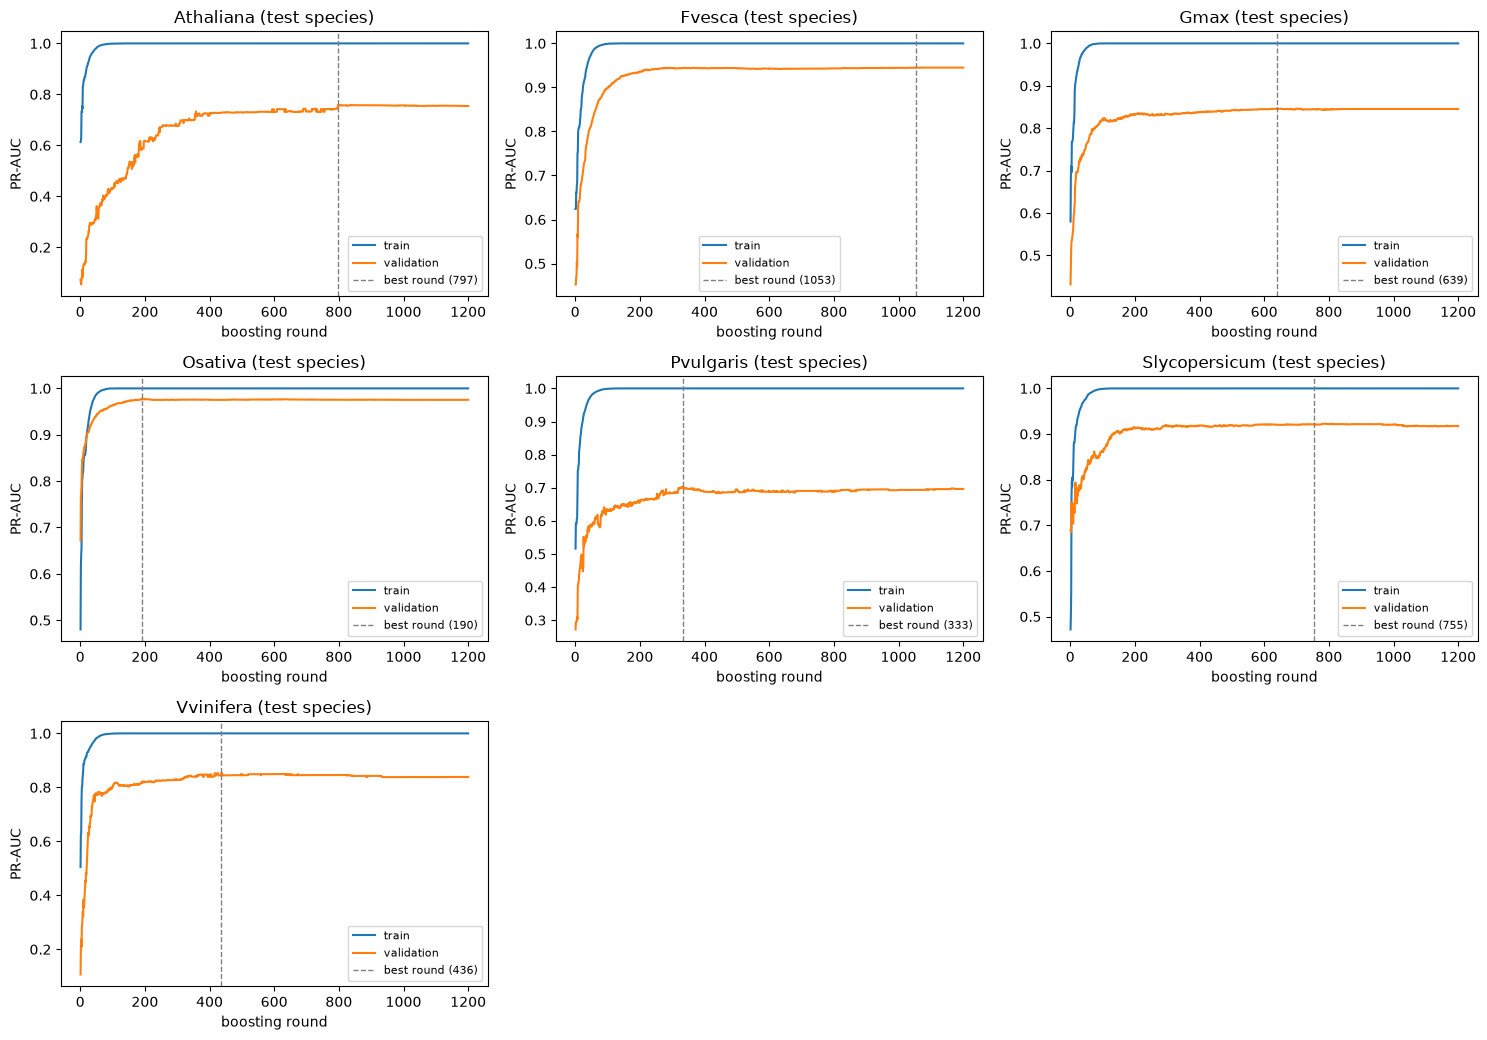

In [39]:
species_list = list(xgb_evaluator.fold_artifacts.keys())
n = len(species_list)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), squeeze=False)

for i, species in enumerate(species_list):
    ax = axes[i // ncols][i % ncols]
    evals = xgb_evaluator.fold_artifacts[species]['evals']
    train_curve = evals['validation_0']['aucpr']
    validation_curve = evals['validation_1']['aucpr']
    rounds = range(1, len(train_curve) + 1)

    ax.plot(rounds, train_curve, label='train', color='tab:blue')
    ax.plot(rounds, validation_curve, label='validation', color='tab:orange')
    best_round = int(xgb_evaluator.fold_results[species]['best_round']) + 1
    ax.axvline(best_round, color='gray', linestyle='--', linewidth=1, label=f'best round ({best_round})')
    ax.set_title(f'{species.split("_")[0]} (test species)')
    ax.set_xlabel('boosting round')
    ax.set_ylabel('PR-AUC')
    ax.legend(fontsize=8)

for j in range(n, nrows * ncols):
    axes[j // ncols][j % ncols].axis('off')

plt.tight_layout()
plt.show()

### Precision-recall graphs

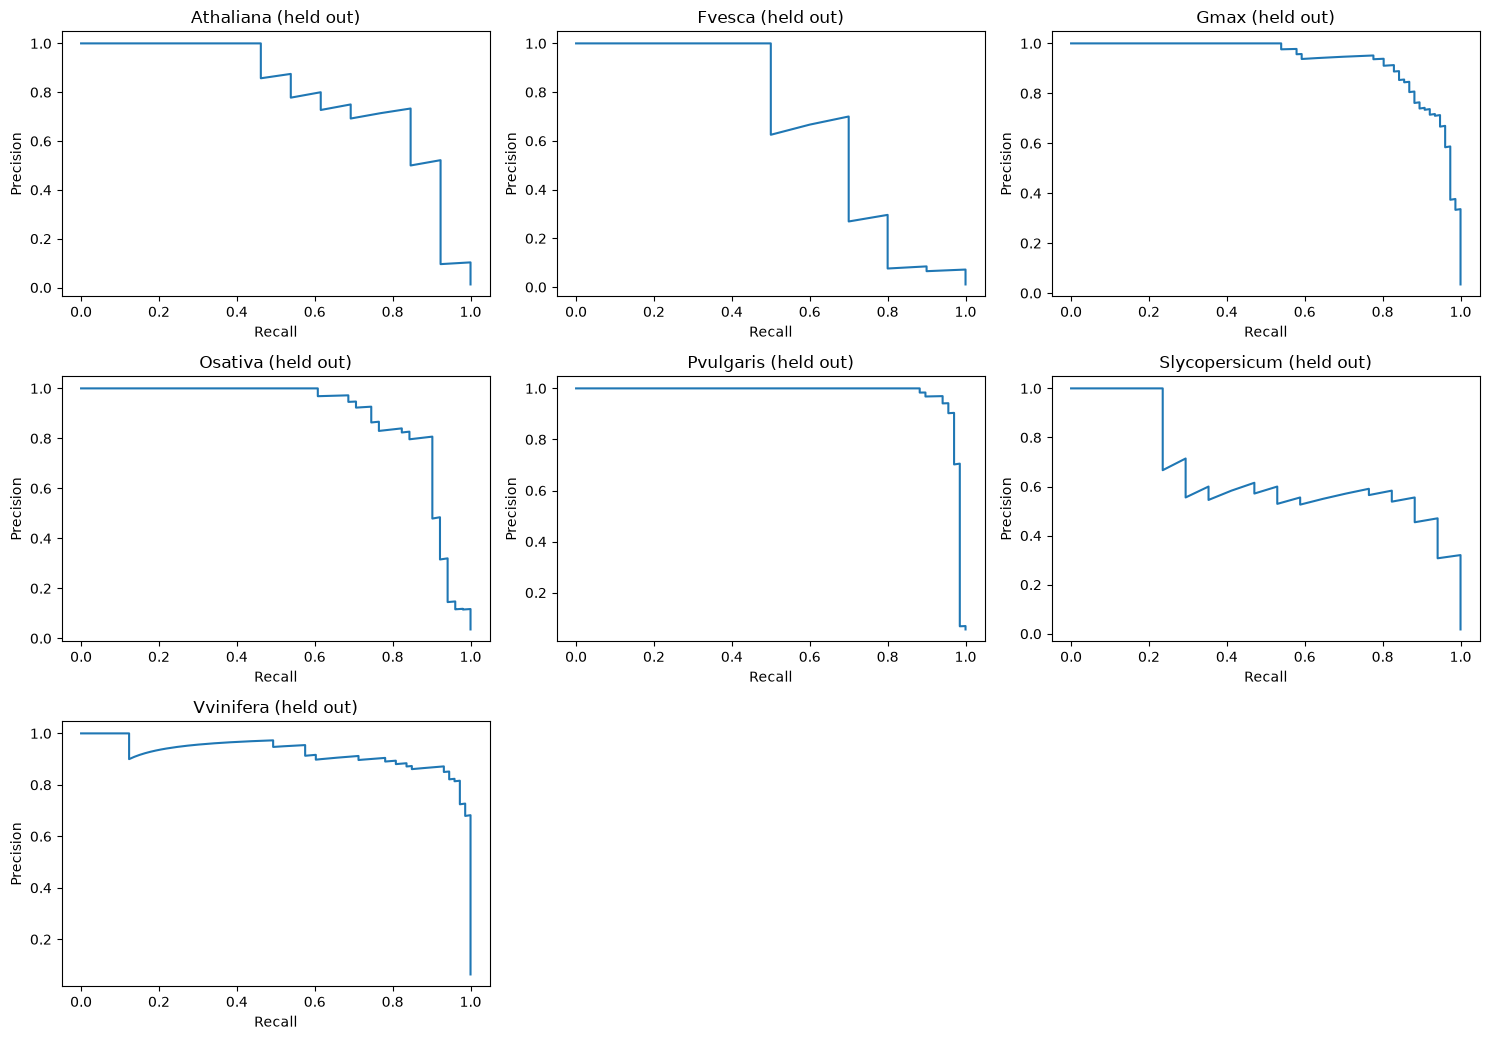

In [40]:
species_list = list(xgb_evaluator.fold_preds.keys())
n = len(species_list)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), squeeze=False)

for i, species in enumerate(species_list):
    ax = axes[i // ncols][i % ncols]
    data = xgb_evaluator.fold_preds[species]
    precisions, recalls, thresholds = precision_recall_curve(data['y_true'], data['preds'])

    ax.plot(recalls, precisions, color='tab:blue')
    ax.set_title(f'{species.split("_")[0]} (held out)')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')

for j in range(n, nrows * ncols):
    axes[j // ncols][j % ncols].axis('off')

plt.tight_layout()
plt.show()

### Precision-recall aggregated

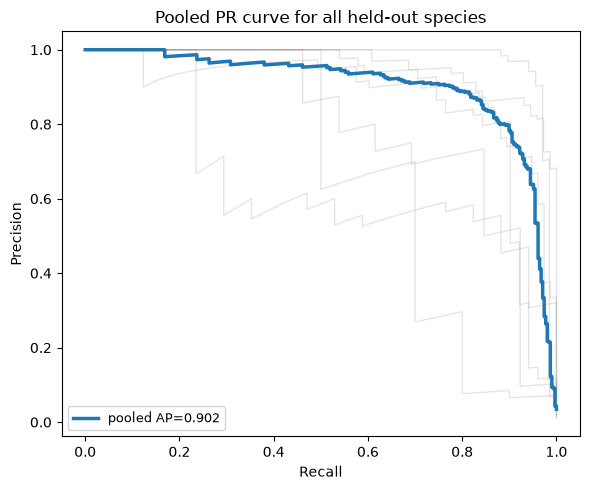

In [41]:
all_y_true = np.concatenate([xgb_evaluator.fold_preds[s]['y_true'] for s in xgb_evaluator.fold_preds])
all_preds = np.concatenate([xgb_evaluator.fold_preds[s]['preds'] for s in xgb_evaluator.fold_preds])

precisions_xgb, recalls_xgb, thresholds_xgb = precision_recall_curve(all_y_true, all_preds)
pr_auc = average_precision_score(all_y_true, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))

for species, data in xgb_evaluator.fold_preds.items():
    p, r, _ = precision_recall_curve(data['y_true'], data['preds'])
    ax.plot(r, p, color='gray', alpha=0.2, linewidth=1)

ax.plot(recalls_xgb, precisions_xgb, color='tab:blue', linewidth=2.5, label=f'pooled AP={pr_auc:.3f}')

ax.set_title('Pooled PR curve for all held-out species')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Recall at FP budgets

In [42]:
def recall_at_fp_budgets(y_true, preds, fp_budgets):
    order = np.argsort(-preds)
    y_sorted = y_true[order]

    n_pos = y_sorted.sum()
    cum_tp = np.cumsum(y_sorted == 1)
    cum_fp = np.cumsum(y_sorted == 0)

    results = {}
    for budget in fp_budgets:
        eligible = np.where(cum_fp <= budget)[0]
        if len(eligible) == 0:
            results[budget] = {'found': 0, 'recall': 0.0, 'actual_fp': 0}
            continue
        idx = eligible[-1]
        results[budget] = {
            'found': int(cum_tp[idx]),
            'recall': cum_tp[idx] / n_pos,
            'actual_fp': int(cum_fp[idx]),
        }
    return results

fp_budgets = [5, 10, 15]

recall_rows = {}
for species, data in xgb_evaluator.fold_preds.items():
    per_budget = recall_at_fp_budgets(data['y_true'], data['preds'], fp_budgets)
    for budget, stats in per_budget.items():
        recall_rows[(species.split('_')[0], budget)] = stats

recall_df = pd.DataFrame(recall_rows).T
recall_df.index.names = ['species', 'fp_budget']
recall_df

found    recall  actual_fp
species       fp_budget                            
Athaliana     5           11.0  0.846154        5.0
              10          11.0  0.846154       10.0
              15          12.0  0.923077       15.0
Fvesca        5            7.0  0.700000        5.0
              10           7.0  0.700000       10.0
              15           7.0  0.700000       15.0
Gmax          5           61.0  0.802632        5.0
              10          64.0  0.842105       10.0
              15          66.0  0.868421       15.0
Osativa       5           38.0  0.745098        5.0
              10          43.0  0.843137       10.0
              15          46.0  0.901961       15.0
Pvulgaris     5           65.0  0.955882        5.0
              10          66.0  0.970588       10.0
              15          66.0  0.970588       15.0
Slycopersicum 5            8.0  0.470588        5.0
              10          14.0  0.823529       10.0
              15          15.0  0.882353       15.0
Vvinifera     5           52.0  0.712329        5.0
              10          68.0  0.931507       10.0
              15          70.0  0.958904       15.0

### Species-specific split details

In [43]:
def specific_results(species_full: str):
    species_short = species_full.split('_')[0]
    df = xgb_evaluator.fold_details[species_full]
    threshold = xgb_evaluator.fold_results[species_full]['threshold']

    predicted_positive = df['pred'] >= threshold
    hits = df[(df['y_true'] == 1) & predicted_positive]
    misses = df[(df['y_true'] == 1) & ~predicted_positive]
    false_positives = df[(df['y_true'] == 0) & predicted_positive]

    print(f"\n{'='*10} {species_short} (test species; threshold={threshold:.3f}) {'='*10}")
    print(f'Hits ({len(hits)}):\n{hits}')
    print(f'\nMisses ({len(misses)}):\n{misses}')
    print(f'\nFalse positives ({len(false_positives)}):\n{false_positives}')

specific_results('Slycopersicum_796_ITAG5.0.protein_primaryTranscriptOnly')
specific_results('Athaliana_447_Araport11.protein_primaryTranscriptOnly')
specific_results('Osativa_204_v7.0.protein_primaryTranscriptOnly')
specific_results('Vvinifera_457_v2.1.protein_primaryTranscriptOnly')
specific_results('Gmax_189_protein_primaryTranscriptOnly')
specific_results('Fvesca_226_v1.1.protein_primaryTranscriptOnly')
specific_results('Pvulgaris_442_v2.1.protein_primaryTranscriptOnly')


========== Slycopersicum (test species; threshold=0.562) ==========
Hits (10):
                  id  y_true      pred
0   Solyc04T000158.1       1  0.999826
1   Solyc05T000401.1       1  0.999790
2   Solyc03T000226.2       1  0.999620
3   Solyc03T001769.1       1  0.999126
6    PRAM_26245.1.p1       1  0.996485
9   Solyc05T000399.1       1  0.991484
11  Solyc02T002539.1       1  0.987322
12  Solyc04T002734.1       1  0.970633
14  Solyc02T001806.1       1  0.962106
17  Solyc03T003214.1       1  0.697235

Misses (7):
                  id  y_true      pred
19  Solyc05T000396.1       1  0.470591
20  Solyc04T000159.1       1  0.302292
21  Solyc05T000406.1       1  0.281983
23  Solyc05T000582.1       1  0.209104
26  Solyc01T000282.1       1  0.143238
33  Solyc01T000276.1       1  0.026663
52  Solyc02T001670.1       1  0.006430

False positives (9):
                  id  y_true      pred
4   Solyc11T000232.1       0  0.998248
5   Solyc11T000233.1       0  0.997825
7   Solyc09T000267.1       

### Feature importance per split

#### Importance Spearman correlation

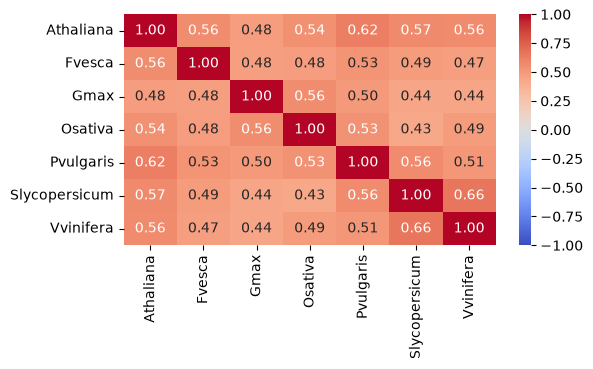

In [44]:
importance_df = pd.DataFrame({
    species.split('_')[0]: artifacts['importance']
    for species, artifacts in xgb_evaluator.fold_artifacts.items()
})

corr_matrix = importance_df.corr(method="spearman")
plt.figure(figsize=(6, 3))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.show()

#### Top features Jaccard similarity

In [45]:
def top_k_jaccard(importance_df, k=20):
    top_sets = {
        species: set(importance_df[species].sort_values(ascending=False).head(k).index)
        for species in importance_df.columns
    }

    species_list = list(top_sets.keys())
    results = {}
    for i in range(len(species_list)):
        for j in range(i+1, len(species_list)):
            a, b = species_list[i], species_list[j]
            intersection = top_sets[a] & top_sets[b]
            union = top_sets[a] | top_sets[b]
            results[(a, b)] = len(intersection) / len(union)

    return results, top_sets

jaccard_scores, top_sets = top_k_jaccard(importance_df, k=20)
for pair, score in jaccard_scores.items():
    print(f"{pair[0]} vs {pair[1]}: {score:.2f}")

common_across_all = set.intersection(*top_sets.values())
print(f"\n{len(common_across_all)} features in every fold's top-20:")
print(common_across_all)

Athaliana vs Fvesca: 0.29
Athaliana vs Gmax: 0.33
Athaliana vs Osativa: 0.33
Athaliana vs Pvulgaris: 0.33
Athaliana vs Slycopersicum: 0.38
Athaliana vs Vvinifera: 0.29
Fvesca vs Gmax: 0.33
Fvesca vs Osativa: 0.29
Fvesca vs Pvulgaris: 0.25
Fvesca vs Slycopersicum: 0.29
Fvesca vs Vvinifera: 0.29
Gmax vs Osativa: 0.33
Gmax vs Pvulgaris: 0.29
Gmax vs Slycopersicum: 0.21
Gmax vs Vvinifera: 0.25
Osativa vs Pvulgaris: 0.29
Osativa vs Slycopersicum: 0.33
Osativa vs Vvinifera: 0.33
Pvulgaris vs Slycopersicum: 0.25
Pvulgaris vs Vvinifera: 0.29
Slycopersicum vs Vvinifera: 0.43

6 features in every fold's top-20:
{'HF', 'CG', 'GC', 'GF', 'DL', 'WC'}


## [LogReg] Model

A simpler model than XGBoost, same purpose as cosine similarity above.

### Train model

In [46]:
class LogRegEvaluator(PUFilterMixin, LOGOEvaluator):
    def make_model_per_split(self, X_train, y_train):
        return make_pipeline(
            StandardScaler(),
            LogisticRegression(class_weight='balanced', max_iter=1000, random_state=2026, C=0.1)
        )

    def extra_metrics_per_split(self, model, X_train, y_train, X_val, y_val):
        return {'n_flagged': getattr(self, '_last_n_flagged', None)}

# Build logistic regression with ESM-2
logreg_evaluator = LogRegEvaluator(
    logo=logo,
    X=X_deduped_esm,
    y=y_deduped,
    groups=groups_deduped,
    auto_threshold=True,
    X_full=X_esm,
    y_full=y,
    groups_full=groups,
    run_pu=RUN_PU,
).fit()

logreg_results = logreg_evaluator.results_df[[
    'species', 'validation_species', 'threshold', 'val_f1_at_threshold',
    'test_pr_auc', 'test_precision', 'test_recall', 'n_pos', 'found',
    'false_positives'
]]
logreg_results

Evaluating: 100%|██████████| 7/7 [01:52<00:00, 16.03s/it, Vvinifera]    


,species,validation_species,threshold,val_f1_at_threshold,test_pr_auc,test_precision,test_recall,n_pos,found,false_positives
Athaliana_447_Araport11.protein_primaryTranscriptOnly,Athaliana,Fvesca,0.900817,0.888889,0.884355,0.6,0.923077,13,12,8
Fvesca_226_v1.1.protein_primaryTranscriptOnly,Fvesca,Gmax,0.844931,0.902778,0.840568,1.0,0.7,10,7,0
Gmax_189_protein_primaryTranscriptOnly,Gmax,Osativa,0.940184,0.9375,0.948286,0.969231,0.828947,90,76,2
Osativa_204_v7.0.protein_primaryTranscriptOnly,Osativa,Pvulgaris,0.768978,0.970588,0.946528,0.978261,0.882353,52,46,1
Pvulgaris_442_v2.1.protein_primaryTranscriptOnly,Pvulgaris,Slycopersicum,0.940792,0.702703,0.973514,0.96875,0.911765,73,67,2
Slycopersicum_796_ITAG5.0.protein_primaryTranscriptOnly,Slycopersicum,Vvinifera,0.708568,0.864198,0.649583,0.518519,0.823529,17,14,13
Vvinifera_457_v2.1.protein_primaryTranscriptOnly,Vvinifera,Athaliana,0.998832,0.916667,0.817904,0.875,0.479452,104,45,5


In [47]:
test_precision = logreg_evaluator.results_df['test_precision']
test_recall = logreg_evaluator.results_df['test_recall']

print("LogReg model (held-out test species)")
print(f"Test precision: {test_precision.mean():.3f}±{test_precision.std():.3f}")
print(f"Test recall:    {test_recall.mean():.3f}±{test_recall.std():.3f}")

LogReg model (held-out test species)
Test precision: 0.844±0.200
Test recall:    0.793±0.157


### Precision-recall aggregated

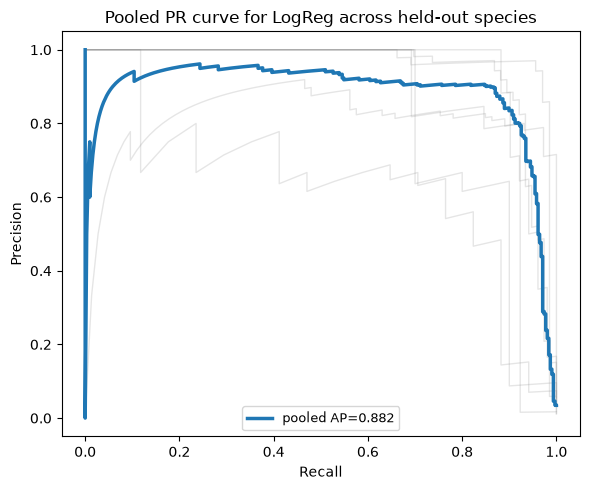

In [48]:
logreg_fold_preds = logreg_evaluator.fold_preds

all_y_true_logreg = np.concatenate([logreg_fold_preds[s]['y_true'] for s in logreg_fold_preds])
all_preds_logreg = np.concatenate([logreg_fold_preds[s]['preds'] for s in logreg_fold_preds])

precisions_logreg, recalls_logreg, thresholds_logreg = precision_recall_curve(all_y_true_logreg, all_preds_logreg)
pr_auc_logreg = average_precision_score(all_y_true_logreg, all_preds_logreg)

fig, ax = plt.subplots(figsize=(6, 5))

for species, data in logreg_fold_preds.items():
    p, r, _ = precision_recall_curve(data['y_true'], data['preds'])
    ax.plot(r, p, color='gray', alpha=0.2, linewidth=1)

ax.plot(
    recalls_logreg, precisions_logreg, color='tab:blue', linewidth=2.5,
    label=f'pooled AP={pr_auc_logreg:.3f}',
)

ax.set_title('Pooled PR curve for LogReg across held-out species')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Meta-model

Combine k-mer XGB and ESM LogReg

### Make meta dataset

In [49]:
xgb_all = pd.concat(xgb_evaluator.fold_details.values()).set_index('id')
lr_all = pd.concat(logreg_evaluator.fold_details.values()).set_index('id')

meta_df = pd.DataFrame({
    'xgb_pred': xgb_all['pred'],
    'lr_pred': lr_all['pred'],
    'y_true': xgb_all['y_true'],
}).dropna()

assert (meta_df['y_true'] == lr_all.loc[meta_df.index, 'y_true']).all(), 'label mismatch between models'

meta_df['diff'] = meta_df['xgb_pred'] - meta_df['lr_pred']
meta_df['abs_diff'] = meta_df['diff'].abs()
meta_df['mean_pred'] = (meta_df['xgb_pred'] + meta_df['lr_pred']) / 2

meta_df['xgb_logit'] = np.log(meta_df['xgb_pred'] / (1 - meta_df['xgb_pred']))
meta_df['lr_logit'] = np.log(meta_df['lr_pred'] / (1 - meta_df['lr_pred']))

species_lookup = pd.Series(groups, index=X_kmer.index, name='species')
meta_df['species'] = species_lookup.reindex(meta_df.index)

assert meta_df['species'].notna().all(), "some ids couldn't be matched to a species"

X_meta = meta_df[['xgb_logit', 'lr_logit']]
y_meta = meta_df['y_true'].values
groups_meta = meta_df['species'].values

X_meta.head()

,xgb_logit,lr_logit
id,,
AT1G01140.3,-11.437797,-13.821997
AT1G01450.1,-6.495376,-5.248047
AT1G01540.2,-9.870847,-6.825416
AT1G01560.2,-7.316952,-7.520791
AT1G01740.2,-10.621427,-11.596143


### Fit

In [50]:
class MetaEvaluator(LOGOEvaluator):
    def make_model_per_split(self, X_train, y_train):
        return LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=2026,
            C=0.1,
        )

meta_evaluator = MetaEvaluator(
    logo=logo,
    X=X_meta,
    y=y_meta,
    groups=groups_meta,
    auto_threshold=True,
)
meta_evaluator.fit()
meta_results = meta_evaluator.results_df[[
    'species', 'validation_species', 'threshold', 'val_f1_at_threshold',
    'test_pr_auc', 'test_precision', 'test_recall', 'n_pos', 'found',
    'false_positives'
]]
meta_results

Evaluating: 100%|██████████| 7/7 [00:04<00:00,  1.55it/s, Vvinifera]    


,species,validation_species,threshold,val_f1_at_threshold,test_pr_auc,test_precision,test_recall,n_pos,found,false_positives
Athaliana_447_Araport11.protein_primaryTranscriptOnly,Athaliana,Fvesca,0.969946,0.823529,0.883654,0.8,0.923077,13,12,3
Fvesca_226_v1.1.protein_primaryTranscriptOnly,Fvesca,Gmax,0.764658,0.935484,0.824493,0.8,0.8,10,8,2
Gmax_189_protein_primaryTranscriptOnly,Gmax,Osativa,0.876062,0.916667,0.968107,0.962963,0.866667,90,78,3
Osativa_204_v7.0.protein_primaryTranscriptOnly,Osativa,Pvulgaris,0.947771,0.965986,0.943963,1.0,0.846154,52,44,0
Pvulgaris_442_v2.1.protein_primaryTranscriptOnly,Pvulgaris,Slycopersicum,0.903236,0.75,0.982189,0.934211,0.972603,73,71,5
Slycopersicum_796_ITAG5.0.protein_primaryTranscriptOnly,Slycopersicum,Vvinifera,0.975621,0.926606,0.679301,0.6,0.705882,17,12,8
Vvinifera_457_v2.1.protein_primaryTranscriptOnly,Vvinifera,Athaliana,0.983082,0.888889,0.950368,0.884956,0.961538,104,100,13


### Pooled PR curve

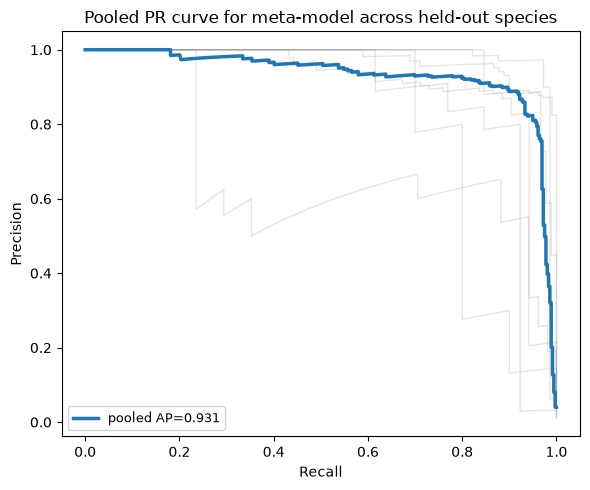

In [51]:
meta_fold_preds = meta_evaluator.fold_preds

all_y_true_meta = np.concatenate([meta_fold_preds[s]['y_true'] for s in meta_fold_preds])
all_preds_meta = np.concatenate([meta_fold_preds[s]['preds'] for s in meta_fold_preds])

precisions_meta, recalls_meta, thresholds_meta = precision_recall_curve(all_y_true_meta, all_preds_meta)
pr_auc_meta = average_precision_score(all_y_true_meta, all_preds_meta)

fig, ax = plt.subplots(figsize=(6, 5))

for species, data in meta_fold_preds.items():
    p, r, _ = precision_recall_curve(data['y_true'], data['preds'])
    ax.plot(r, p, color='gray', alpha=0.2, linewidth=1)

ax.plot(
    recalls_meta, precisions_meta, color='tab:blue', linewidth=2.5,
    label=f'pooled AP={pr_auc_meta:.3f}',
)

ax.set_title('Pooled PR curve for meta-model across held-out species')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Model comaprison

### Boxplots

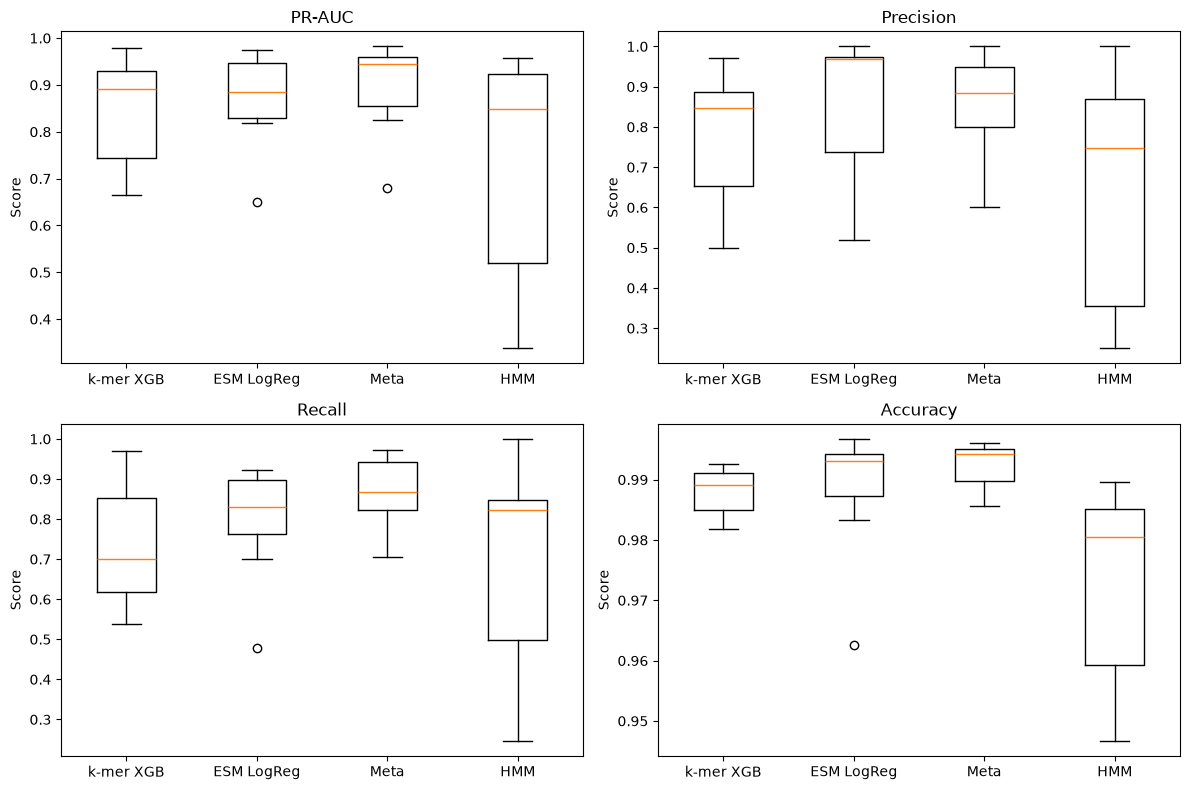

In [52]:
models = {
    'k-mer XGB': xgb_evaluator,
    'ESM LogReg': logreg_evaluator,
    'Meta': meta_evaluator,
}
model_labels = list(models)

precision = np.array([
    [result['test_precision'] for result in evaluator.fold_results.values()]
    for evaluator in models.values()
] + [hmm_fold_results['precision']])
recall = np.array([
    [result['test_recall'] for result in evaluator.fold_results.values()]
    for evaluator in models.values()
] + [hmm_fold_results['recall']])
accuracy = np.array([
    [result.get(
        'test_accuracy',
        accuracy_score(
            evaluator.fold_preds[species]['y_true'],
            evaluator.fold_preds[species]['preds'] >= result.get('threshold', 0.5),
        ),
    ) for species, result in evaluator.fold_results.items()]
    for evaluator in models.values()
] + [hmm_fold_results['accuracy']])
pr_auc = np.array([
    [result['test_pr_auc'] for result in evaluator.fold_results.values()]
    for evaluator in models.values()
] + [hmm_fold_results['test_pr_auc']])

metrics = {
    'PR-AUC': (pr_auc, model_labels + ['HMM']),
    'Precision': (precision, model_labels + ['HMM']),
    'Recall': (recall, model_labels + ['HMM']),
    'Accuracy': (accuracy, model_labels + ['HMM']),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (metric_name, (scores, labels)) in zip(axes.flat, metrics.items()):
    ax.boxplot(
        scores.T,
        tick_labels=labels
    )
    ax.set_title(metric_name)
    ax.set_ylabel('Score')
    # if metric_name != 'Accuracy':
    #     ax.set_ylim(0, 1)
    # else:
    #     ax.set_ylim(0.9, 1)

plt.tight_layout()
plt.show()

### Friedman & Nemenyi

https://www.jmlr.org/papers/volume7/demsar06a/demsar06a.pdf

PR-AUC: Friedman chi2=9.171, p=0.0271
Accuracy: Friedman chi2=15.261, p=0.001607
Precision: Friedman chi2=9.343, p=0.02506
Recall: Friedman chi2=2.500, p=0.4753
  Omnibus test is not significant.


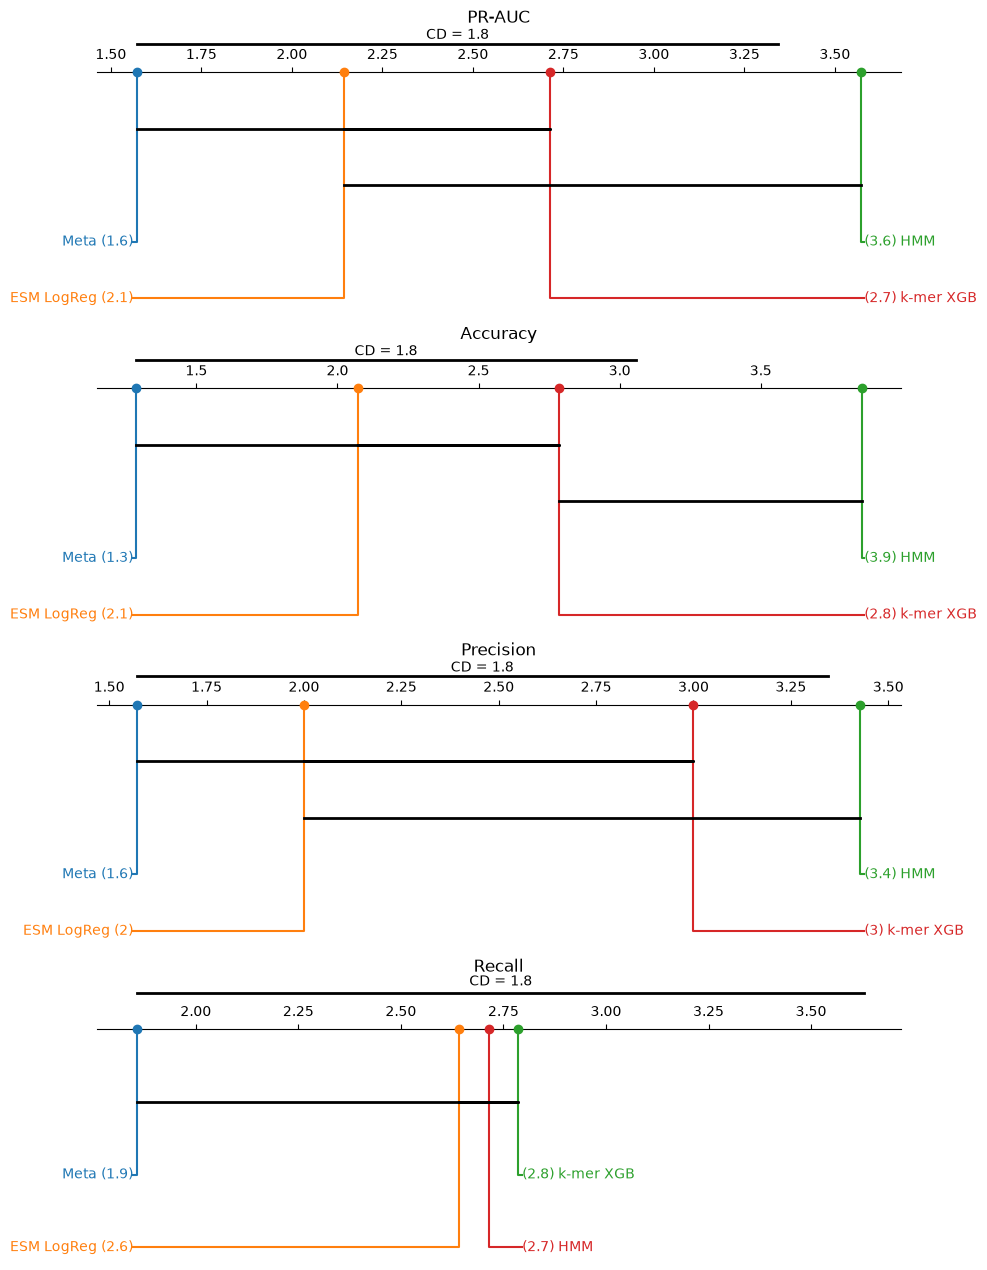

,n_folds,chi2,p_value,significant_at_0.05,best_average_rank
metric,,,,,
PR-AUC,7,9.1714,0.0271,True,Meta
Accuracy,7,15.2609,0.0016,True,Meta
Precision,7,9.3429,0.0251,True,Meta
Recall,7,2.5000,0.4753,False,Meta


In [53]:
ALPHA = 0.05
METHODS = list(models.keys()) + ['HMM']

def _species_key(name):
    return str(name).split('_')[0]

def _test_metric(evaluator, species, result, metric):
    if metric in result:
        return result[metric]
    values = evaluator.fold_preds[species]
    y_true = values['y_true']
    preds = values['preds']
    hard = preds >= result.get('threshold', 0.5)
    if metric == 'test_pr_auc':
        return average_precision_score(y_true, preds)
    if metric == 'test_precision':
        return precision_score(y_true, hard, zero_division=0)
    if metric == 'test_recall':
        return recall_score(y_true, hard, zero_division=0)
    if metric == 'test_accuracy':
        return accuracy_score(y_true, hard)
    raise KeyError(metric)

fold_species = [_species_key(name) for name in models[METHODS[0]].fold_results.keys()]
hmm_species = hmm_fold_results['species'].astype(str).tolist()
if set(fold_species) != set(hmm_species):
    raise ValueError(f'Fold mismatch between ML models and HMM baseline: {fold_species} vs {hmm_species}')

metric_columns = {
    'PR-AUC': ('test_pr_auc', 'test_pr_auc'),
    'Accuracy': ('test_accuracy', 'accuracy'),
    'Precision': ('test_precision', 'precision'),
    'Recall': ('test_recall', 'recall'),
}
scores_by_metric = {}
for metric_name, (result_key, hmm_key) in metric_columns.items():
    score_frame = pd.DataFrame({
        method: {
            _species_key(species): float(_test_metric(evaluator, species, result, result_key))
            for species, result in evaluator.fold_results.items()
        }
        for method, evaluator in models.items()
    })
    hmm_values = hmm_fold_results.set_index('species')[hmm_key].astype(float)
    score_frame['HMM'] = hmm_values.reindex(score_frame.index)
    score_frame = score_frame.reindex(columns=METHODS)
    if score_frame.isna().any().any():
        raise ValueError(f'Missing {metric_name} scores after fold alignment')
    scores_by_metric[metric_name] = score_frame

friedman_summary = []
nemenyi_results = {}
cd_values = {}

fig, axes = plt.subplots(len(scores_by_metric), 1, figsize=(10, 3.2 * len(scores_by_metric)))
if len(scores_by_metric) == 1:
    axes = [axes]

for ax, (metric_name, score_frame) in zip(axes, scores_by_metric.items()):
    statistic, p_value = friedmanchisquare(*[score_frame[method] for method in METHODS])
    ranks = score_frame.rank(axis=1, ascending=False, method='average')
    rank_means = ranks.mean(axis=0)
    nemenyi_pvalues = sp.posthoc_nemenyi_friedman(-score_frame)
    nemenyi_pvalues = nemenyi_pvalues.reindex(index=METHODS, columns=METHODS)
    n_blocks, n_methods = ranks.shape
    cd = studentized_range.ppf(1 - ALPHA, n_methods, np.inf) / np.sqrt(2) * np.sqrt(
        n_methods * (n_methods + 1) / (6 * n_blocks)
    )
    friedman_summary.append({
        'metric': metric_name,
        'n_folds': n_blocks,
        'chi2': statistic,
        'p_value': p_value,
        'significant_at_0.05': p_value < ALPHA,
        'best_average_rank': rank_means.idxmin(),
    })
    cd_values[metric_name] = cd
    nemenyi_results[metric_name] = nemenyi_pvalues if p_value < ALPHA else None
    if p_value < ALPHA:
        print(f'{metric_name}: Friedman chi2={statistic:.3f}, p={p_value:.4g}')
    else:
        print(f'{metric_name}: Friedman chi2={statistic:.3f}, p={p_value:.4g}')
        print('  Omnibus test is not significant.')

    sp.critical_difference_diagram(
        rank_means,
        nemenyi_pvalues,
        cd=cd,
        alpha=ALPHA,
        ax=ax,
        label_props={'fontsize': 10},
    )
    ax.set_title(metric_name)

plt.tight_layout()
plt.show()

friedman_summary_df = pd.DataFrame(friedman_summary).set_index('metric')
display(friedman_summary_df.round(4))

## Failure analysis

In [54]:
def get_miss_fp_sets(evaluator):
    misses, fps = set(), set()
    for species, details in evaluator.fold_details.items():
        threshold = evaluator.fold_results[species]['threshold']
        pred_pos = details['pred'] >= threshold
        misses.update(details[(details['y_true'] == 1) & ~pred_pos]['id'])
        fps.update(details[(details['y_true'] == 0) & pred_pos]['id'])
    return misses, fps

all_evaluators = {
    'lr_esm': logreg_evaluator,
    'xgb_kmer': xgb_evaluator,
    'meta': meta_evaluator,
}

miss_sets = {}
fp_sets = {}
for name, ev in all_evaluators.items():
    m, f = get_miss_fp_sets(ev)
    miss_sets[name] = m
    fp_sets[name] = f

miss_counter = Counter()
for s in miss_sets.values():
    miss_counter.update(s)

fp_counter = Counter()
for s in fp_sets.values():
    fp_counter.update(s)

n_models = len(all_evaluators)
print(f"Misses by agreement level (out of {n_models} models):")
print(pd.Series(miss_counter.values()).value_counts().sort_index())
print(f"\nFPs by agreement level (out of {n_models} models):")
print(pd.Series(fp_counter.values()).value_counts().sort_index())

# majority (2 of 3) as "hard" cases
majority_misses = {k for k,v in miss_counter.items() if v >= 2}
majority_fps = {k for k,v in fp_counter.items() if v >= 2}
print(f"\nMajority (2+/3) misses: {len(majority_misses)}")
print(f"Majority (2+/3) FPs: {len(majority_fps)}")

xgb_pooled_probs = pd.concat(xgb_evaluator.fold_details.values()).set_index('id')
uncertain = xgb_pooled_probs[(xgb_pooled_probs['pred'] > 0.35) & (xgb_pooled_probs['pred'] < 0.65)]
print(f"{len(uncertain)} examples XGB is uncertain about")

Misses by agreement level (out of 3 models):
1    95
2    29
Name: count, dtype: int64

FPs by agreement level (out of 3 models):
1    50
2    14
Name: count, dtype: int64

Majority (2+/3) misses: 29
Majority (2+/3) FPs: 14
36 examples XGB is uncertain about


In [55]:
species_lookup = pd.Series(groups, index=X_kmer.index)

miss_species = species_lookup.reindex(list(majority_misses)).value_counts()
fp_species = species_lookup.reindex(list(majority_fps)).value_counts()

n_pos_by_species = pd.Series(y, index=X_kmer.index)[pd.Series(y, index=X_kmer.index) == 1] \
    .groupby(species_lookup).size()

error_species_df = pd.DataFrame({
    'misses': miss_species,
    'fps': fp_species,
    'n_pos': n_pos_by_species,
}).fillna(0).astype(int)

error_species_df['total_errors'] = error_species_df['misses'] + error_species_df['fps']
error_species_df['error_rate'] = error_species_df['total_errors'] / error_species_df['n_pos']

error_species_df = error_species_df[['total_errors', 'misses', 'fps', 'n_pos', 'error_rate']] \
    .sort_values('error_rate', ascending=False)

print(error_species_df)

                                                    total_errors  misses  fps  \
Slycopersicum_796_ITAG5.0.protein_primaryTransc...            11       3    8   
Fvesca_226_v1.1.protein_primaryTranscriptOnly                  2       2    0   
Athaliana_447_Araport11.protein_primaryTranscri...             2       1    1   
Osativa_204_v7.0.protein_primaryTranscriptOnly                 6       6    0   
Gmax_189_protein_primaryTranscriptOnly                         9       8    1   
Vvinifera_457_v2.1.protein_primaryTranscriptOnly               9       7    2   
Pvulgaris_442_v2.1.protein_primaryTranscriptOnly               4       2    2   

                                                    n_pos  error_rate  
Slycopersicum_796_ITAG5.0.protein_primaryTransc...     17    0.647059  
Fvesca_226_v1.1.protein_primaryTranscriptOnly          10    0.200000  
Athaliana_447_Araport11.protein_primaryTranscri...     13    0.153846  
Osativa_204_v7.0.protein_primaryTranscriptOnly         52    0.

### Inspect tomato

In [56]:
sly_mask = species_lookup.str.startswith('Slycopersicum')
sly_errors = (majority_misses | majority_fps) & set(species_lookup[sly_mask].index)
for e in sly_errors:
    print(e)

Solyc05T000170.1
Solyc05T000406.1
Solyc02T001670.1
Solyc11T000233.1
Solyc09T000267.1
Solyc11T000232.1
Solyc10T000016.1
Solyc01T000282.1
Solyc12T002359.1
Solyc09T000535.1
Solyc01T000275.1


### Score distribution

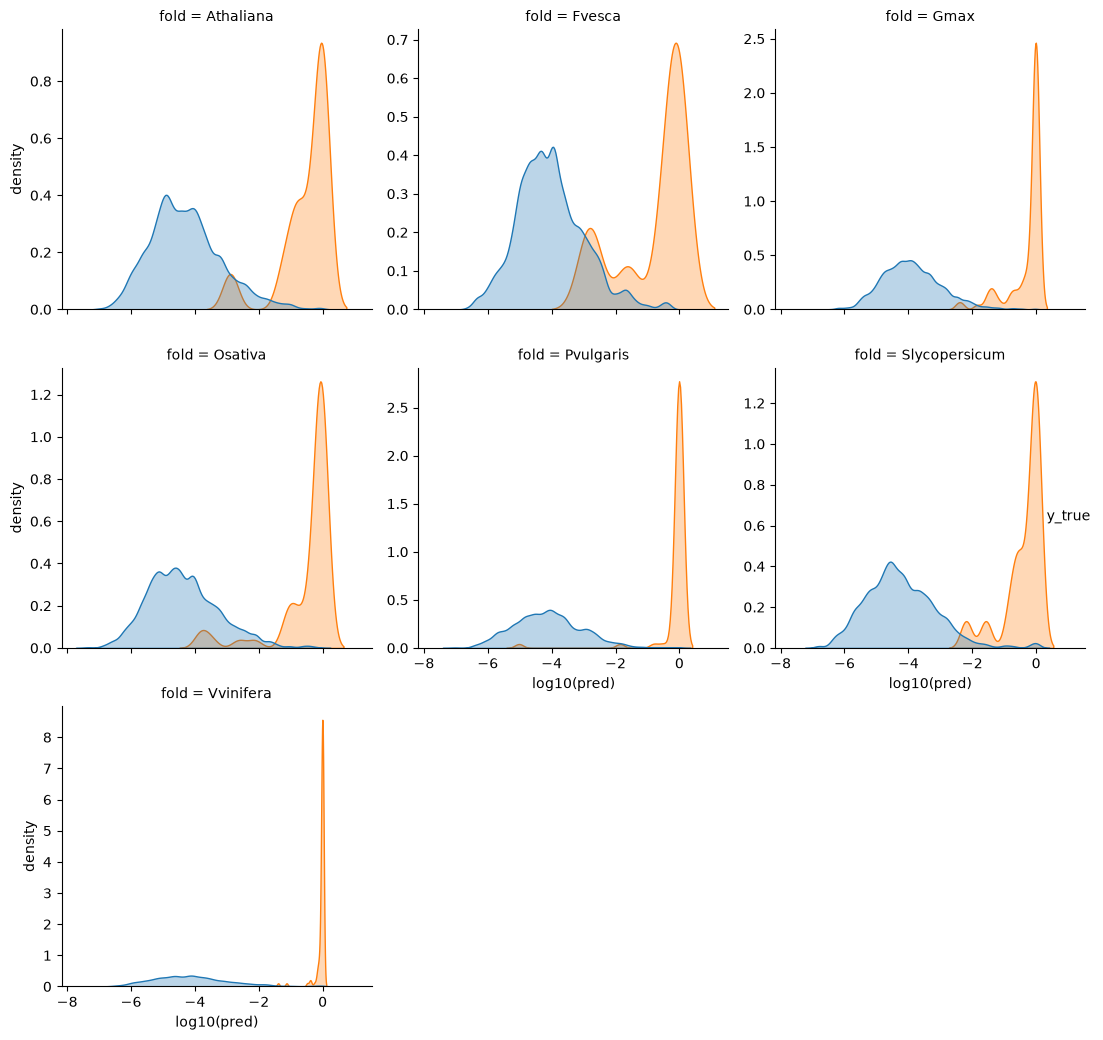

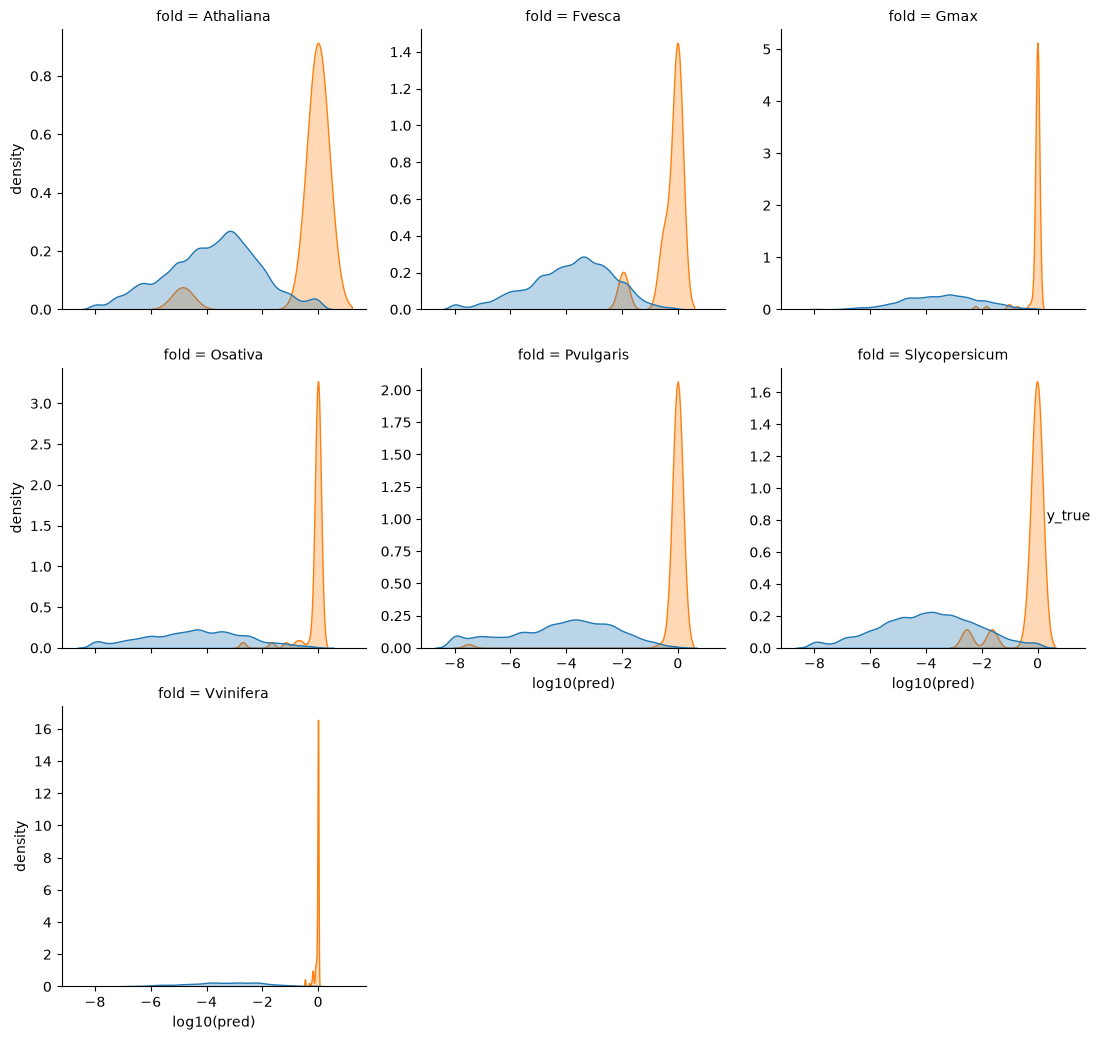

In [57]:
def plot_fold_score_kde(fold_details, eps=1e-8, bw_adjust=0.5):
    # combine all folds into one long dataframe with a fold label
    dfs = []
    for fold_name, df in fold_details.items():
        d = df[['y_true', 'pred']].copy()
        d['fold'] = str(fold_name.split('_')[0])
        dfs.append(d)
    all_df = pd.concat(dfs, ignore_index=True)

    all_df['log_pred'] = np.log10(all_df['pred'].clip(lower=eps))

    g = sns.FacetGrid(all_df, col='fold', col_wrap=3, height=3.5, sharex=True, sharey=False)
    g.map_dataframe(
        sns.kdeplot, x='log_pred', hue='y_true',
        common_norm=False, fill=True, alpha=0.3, bw_adjust=bw_adjust
    )
    g.add_legend(title='y_true')
    g.set_axis_labels('log10(pred)', 'density')
    plt.tight_layout()
    return g

g = plot_fold_score_kde(xgb_evaluator.fold_details)
plt.show()
g = plot_fold_score_kde(logreg_evaluator.fold_details)
plt.show()

### Error overlap

In [58]:
def collect_error_sets(evaluator):
    false_positives, false_negatives = set(), set()

    if evaluator.fold_details:
        fold_rows = (
            (species, details['id'], details['y_true'], details['pred'])
            for species, details in evaluator.fold_details.items()
        )
    else:
        fold_rows = (
            (
                species,
                evaluator.X.index[evaluator.groups == species],
                predictions['y_true'],
                predictions['preds'],
            )
            for species, predictions in evaluator.fold_preds.items()
        )

    for species, ids, y_true, predictions in fold_rows:
        threshold = evaluator.fold_results[species]['threshold']
        predicted_positive = predictions >= threshold
        false_positives.update(ids[(y_true == 0) & predicted_positive])
        false_negatives.update(ids[(y_true == 1) & ~predicted_positive])

    return {
        'false_positives': false_positives,
        'false_negatives': false_negatives,
    }


def collect_hmm_error_sets(hmm_results):
    test_results = hmm_results[hmm_results['split'] == 'test']
    return {
        'false_positives': set(test_results.loc[
            (test_results['true_label'] == 0) & (test_results['pred_label'] == 1),
            'record_id',
        ]),
        'false_negatives': set(test_results.loc[
            (test_results['true_label'] == 1) & (test_results['pred_label'] == 0),
            'record_id',
        ]),
    }


error_sets = {
    'k-mer XGB': collect_error_sets(xgb_evaluator),
    'ESM LogReg': collect_error_sets(logreg_evaluator),
    'Meta': collect_error_sets(meta_evaluator),
    'HMM': collect_hmm_error_sets(hmm_results_df),
}


def error_overlap_table(error_sets, error_type):
    rows = []
    names = list(error_sets)
    for i, model_a in enumerate(names):
        for model_b in names[i + 1:]:
            errors_a = error_sets[model_a][error_type]
            errors_b = error_sets[model_b][error_type]
            union = errors_a | errors_b
            intersection = errors_a & errors_b
            rows.append({
                'model_a': model_a,
                'model_b': model_b,
                'errors_a': len(errors_a),
                'errors_b': len(errors_b),
                'overlap': len(intersection),
                'jaccard': len(intersection) / len(union) if union else 1.0,
                'only_a': len(errors_a - errors_b),
                'only_b': len(errors_b - errors_a),
            })
    return pd.DataFrame(rows)


for error_type, label in [('false_positives', 'false positives'), ('false_negatives', 'false negatives')]:
    print(f'\n{label.title()} by model:')
    print(pd.Series({model: len(errors[error_type]) for model, errors in error_sets.items()}))
    display(error_overlap_table(error_sets, error_type).sort_values('jaccard', ascending=False))


for error_type, label in [('false_positives', 'false positives'), ('false_negatives', 'false negatives')]:
    all_errors = set.union(*(errors[error_type] for errors in error_sets.values()))
    agreement = Counter(
        sum(protein in errors[error_type] for errors in error_sets.values())
        for protein in all_errors
    )
    print(f'\n{label.title()} agreement across models:')
    print(pd.Series(agreement).sort_index().rename('n_proteins').rename_axis('n_models'))


common_false_positives = set.intersection(*(errors['false_positives'] for errors in error_sets.values()))
common_false_negatives = set.intersection(*(errors['false_negatives'] for errors in error_sets.values()))
print(f'\nFalse positives shared by all four methods ({len(common_false_positives)}): {sorted(common_false_positives)}')
print(f'False negatives shared by all four methods ({len(common_false_negatives)}): {sorted(common_false_negatives)}')


False Positives by model:
k-mer XGB      47
ESM LogReg     31
Meta           34
HMM           102
dtype: int64


,model_a,model_b,errors_a,errors_b,overlap,jaccard,only_a,only_b
1,k-mer XGB,Meta,47,34,29,0.557692,18,5
3,ESM LogReg,Meta,31,34,18,0.382979,13,16
0,k-mer XGB,ESM LogReg,47,31,14,0.218750,33,17
4,ESM LogReg,HMM,31,102,13,0.108333,18,89
5,Meta,HMM,34,102,12,0.096774,22,90
2,k-mer XGB,HMM,47,102,10,0.071942,37,92



False Negatives by model:
k-mer XGB      61
ESM LogReg     92
Meta           34
HMM           127
dtype: int64


,model_a,model_b,errors_a,errors_b,overlap,jaccard,only_a,only_b
1,k-mer XGB,Meta,61,34,31,0.484375,30,3
4,ESM LogReg,HMM,92,127,62,0.394904,30,65
3,ESM LogReg,Meta,92,34,28,0.285714,64,6
0,k-mer XGB,ESM LogReg,61,92,29,0.233871,32,63
2,k-mer XGB,HMM,61,127,27,0.167702,34,100
5,Meta,HMM,34,127,21,0.150000,13,106



False Positives agreement across models:
n_models
1    111
2     21
3     11
4      7
Name: n_proteins, dtype: int64

False Negatives agreement across models:
n_models
1    95
2    51
3    19
4    15
Name: n_proteins, dtype: int64

False positives shared by all four methods (7): ['AT4G18250.1', 'Solyc01T000275.1', 'Solyc09T000267.1', 'Solyc11T000232.1', 'Solyc11T000233.1', 'Solyc12T002359.1', 'VIT_214s0006g02600.2']
False negatives shared by all four methods (15): ['Glyma02g33910.2', 'Glyma07g10751.2', 'Glyma18g40680.1', 'Glyma18g47480.2', 'LOC_Os03g12470.1', 'LOC_Os03g58750.1', 'LOC_Os05g25390.1', 'LOC_Os12g40419.1', 'Phvul.001G000500.1.p', 'Phvul.009G259800.1.p', 'Solyc01T000282.1', 'VIT_201s0011g04280.1', 'VIT_216s0148g00070.1', 'mrna18355.1-v1.0-hybrid', 'mrna20850.1-v1.0-hybrid']


## --------------------------------------

## PU-clean full dataset

In [59]:
if RUN_PU:
    pos_idx_full = np.where(y_deduped == 1)[0]
    neg_idx_full = np.where(y_deduped == 0)[0]

    pu_scores_full, n_oob_full = run_pu_bagging(
        X_deduped_kmer, y_deduped, pos_idx_full, neg_idx_full,
        n_iter=N_ITER, neg_sample_ratio=NEG_SAMPLE_RATIO, seed=2026,
    )
    flagged_full_mask = pu_scores_full >= 0.8
    flagged_full_ids = set(X_deduped_kmer.index[neg_idx_full[flagged_full_mask]])

    print(f'{len(flagged_full_ids)} proteins flagged for removal (pu_score >= 0.8)')

    clean_mask_full = ~X_deduped_kmer.index.isin(flagged_full_ids)
    X_clean_full = X_deduped_kmer[clean_mask_full]
    y_clean_full = y_deduped[clean_mask_full]
    groups_clean_full = groups_deduped[clean_mask_full]

    print(f'{len(y_deduped) - len(y_clean_full)} proteins removed')
    print(f'{y_clean_full.sum()} positives remain, {(y_clean_full == 0).sum()} negatives remain')
else:
    print('Did not run PU')
    X_clean_full = X_deduped_kmer.copy()
    y_clean_full = y_deduped.copy()
    groups_clean_full = groups_deduped.copy()

8 proteins flagged for removal (pu_score >= 0.8)
8 proteins removed
308 positives remain, 8578 negatives remain


## Full model

Build a full model using all species and analyze features. Could also be used for extra test inference in the future.

### Fit full model

In [60]:
scale_pos_weight_full = get_scale_pos_weight(y_clean_full)

model_full = make_model(scale_pos_weight_full)
model_full.fit(X_clean_full, y_clean_full)

print(f'{(y_clean_full == 1).sum()} positives, {(y_clean_full == 0).sum()} negatives')
print(f'scale_pos_weight_full = {scale_pos_weight_full:.2f}')

308 positives, 8578 negatives
scale_pos_weight_full = 27.85


### Feature importance

In [61]:
importances = model_full.feature_importances_
imp_df = pd.DataFrame({
    'kmer': X_clean_full.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

display(imp_df.head())

,kmer,importance
361,WC,0.070595
101,GC,0.069688
146,IH,0.037375
81,FC,0.036125
49,DL,0.034553


## Misc analysis

### Model quality / complexity

#### Baseline cosine

Establish a baseline using cosine similarity instead of a model.

"Does XGBoost actually need the complexity?"

In [62]:
cos_fold_results = {}

for train_idx, val_idx in logo.split(X_deduped_kmer, y_deduped, groups=groups_deduped):
    held_out_species = groups_deduped[val_idx][0]
    n_pos_val = y_deduped[val_idx].sum()
    n_total_val = len(val_idx)
    baseline = n_pos_val / n_total_val

    X_train = X_deduped_kmer.iloc[train_idx]
    X_val = X_deduped_kmer.iloc[val_idx]

    centroid = X_train[y_deduped[train_idx] == 1].mean(axis=0)
    similarity_scores = cosine_similarity(X_val, centroid.values.reshape(1, -1)).flatten()
    score = average_precision_score(y_deduped[val_idx], similarity_scores)
    lift = score / baseline

    cos_fold_results[held_out_species] = {
        'baseline': baseline,
        'pr_auc': score,
        'lift': lift,
        'n_pos': n_pos_val,
    }

cos_results_df = pd.DataFrame(cos_fold_results).T
cos_results_df

,baseline,pr_auc,lift,n_pos
Athaliana_447_Araport11.protein_primaryTranscriptOnly,0.012808,0.221664,17.306856,13.0
Fvesca_226_v1.1.protein_primaryTranscriptOnly,0.010823,0.026278,2.428067,10.0
Gmax_189_protein_primaryTranscriptOnly,0.034640,0.116433,3.361245,76.0
Osativa_204_v7.0.protein_primaryTranscriptOnly,0.035565,0.146295,4.113465,51.0
Pvulgaris_442_v2.1.protein_primaryTranscriptOnly,0.055829,0.264868,4.744259,68.0
Slycopersicum_796_ITAG5.0.protein_primaryTranscriptOnly,0.017745,0.269483,15.186143,17.0
Vvinifera_457_v2.1.protein_primaryTranscriptOnly,0.063423,0.098995,1.560871,73.0


#### Logistic regression for species identity

Check for potential phylogenetic leak rather than data leak.

"Is species identity easily identifiable from k-mer features?"

In [63]:
species_clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=1000,
        random_state=2026,
    )
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2026)
scores = cross_val_score(species_clf, X_deduped_kmer, groups_deduped, cv=cv, scoring='accuracy')

print(f'Species prediction accuracy (5-fold CV): {scores.mean():.3f} +/- {scores.std():.3f}')
print(f'Chance baseline (majority class): {pd.Series(groups_deduped).value_counts(normalize=True).max():.3f}')
print(f'Chance baseline (random guess, {len(set(groups_deduped))} classes): {1/len(set(groups_deduped)):.3f}')

Species prediction accuracy (5-fold CV): 0.376 +/- 0.013
Chance baseline (majority class): 0.247
Chance baseline (random guess, 7 classes): 0.143


### K-mer matrix similarity

#### Inter-species

In [64]:
pos_mask = y_deduped == 1
X_pos = X_deduped_kmer[pos_mask]
species_pos = groups_deduped[pos_mask]
ids_pos = X_pos.index

sim_matrix = cosine_similarity(X_pos)

rows = []
for i in range(len(ids_pos)):
    for j in range(i+1, len(ids_pos)):
        if species_pos[i] != species_pos[j]:
            rows.append({
                'protein_a': ids_pos[i],
                'protein_b': ids_pos[j],
                'similarity': sim_matrix[i, j],
            })

sim_df = pd.DataFrame(rows).sort_values('similarity', ascending=False)
sim_df.head()

,protein_a,protein_b,similarity
36706,Phvul.001G236600.1.p,Glyma11g34490.1,0.943215
37412,Phvul.001G184100.1.p,Glyma19g37290.1,0.938718
33865,Phvul.008G115500.1.p,Glyma07g16450.1,0.923891
37713,Phvul.002G318300.1.p,Glyma05g34780.1,0.923087
37866,Phvul.002G023400.1.p,Glyma01g38920.1,0.920614


#### Intra-species, positive

In [65]:
within_species_pos_rows = []

for species in sorted(set(groups_deduped)):
    mask = (groups_deduped == species) & (y_deduped == 1)
    X_sub = X_deduped_kmer[mask]
    ids_sub = X_sub.index
    if len(ids_sub) < 2:
        continue

    sim = cosine_similarity(X_sub)
    for i in range(len(ids_sub)):
        for j in range(i + 1, len(ids_sub)):
            within_species_pos_rows.append({
                'species': species.split('_')[0],
                'protein_a': ids_sub[i],
                'protein_b': ids_sub[j],
                'similarity': sim[i, j],
            })

within_species_pos_sim = pd.DataFrame(within_species_pos_rows)
top_intra_sim = within_species_pos_sim[within_species_pos_sim['similarity'] >= 0.95].sort_values('similarity', ascending=False)
print(len(top_intra_sim))
top_intra_sim

4


,species,protein_a,protein_b,similarity
9059,Vvinifera,VIT_216s0148g00290.1,VIT_216s0148g00360.1,0.985101
7723,Vvinifera,VIT_216s0098g00020.1,VIT_216s0148g00030.1,0.968919
1262,Gmax,Glyma17g32691.1,Glyma17g32731.1,0.968104
3655,Osativa,LOC_Os01g02600.1,LOC_Os01g02400.1,0.965859


#### Intra-species, negative, random sample

In [66]:
rng = np.random.default_rng(2026)

def sampled_pairwise_sim(X_sub, ids_sub, n_pairs=2000):
    n = len(ids_sub)
    vecs = X_sub.values
    idx_a = rng.integers(0, n, size=n_pairs)
    idx_b = rng.integers(0, n, size=n_pairs)
    keep = idx_a != idx_b
    idx_a, idx_b = idx_a[keep], idx_b[keep]

    num = np.sum(vecs[idx_a] * vecs[idx_b], axis=1)
    denom = np.linalg.norm(vecs[idx_a], axis=1) * np.linalg.norm(vecs[idx_b], axis=1)
    sims = np.divide(num, denom, out=np.zeros_like(num), where=denom > 0)

    return pd.DataFrame({
        'protein_a': ids_sub[idx_a],
        'protein_b': ids_sub[idx_b],
        'similarity': sims,
    })

baseline_rows = []
for species in sorted(set(groups_deduped)):
    mask = (groups_deduped == species) & (y_deduped == 0)
    X_sub = X_deduped_kmer[mask]
    ids_sub = X_sub.index
    df = sampled_pairwise_sim(X_sub, ids_sub, n_pairs=2000)
    df['species'] = species.split('_')[0]
    baseline_rows.append(df)

baseline_neg_sim = pd.concat(baseline_rows, ignore_index=True)
baseline_neg_sim.sort_values('similarity', ascending=False).head(10)

,protein_a,protein_b,similarity,species
4651,Glyma18g44630.1,Glyma09g41160.1,0.984757,Gmax
9965,Phvul.005G163500.1.p,Phvul.005G162500.1.p,0.948623,Pvulgaris
5904,Glyma11g37500.1,Glyma05g27650.3,0.937166,Gmax
4125,Glyma19g40820.1,Glyma02g01150.1,0.929539,Gmax
6272,LOC_Os01g12790.1,LOC_Os11g10310.1,0.919374,Osativa
6087,LOC_Os04g04330.1,LOC_Os05g07740.1,0.918114,Osativa
8430,Phvul.006G059284.1.p,Phvul.003G203100.1.p,0.910234,Pvulgaris
1305,AT5G07280.1,AT1G73080.1,0.897868,Athaliana
12737,VIT_208s0007g02110.1,VIT_200s0658g00020.1,0.897820,Vvinifera
895,AT5G44700.1,AT4G36180.1,0.891753,Athaliana


#### Cosine similarity distribution

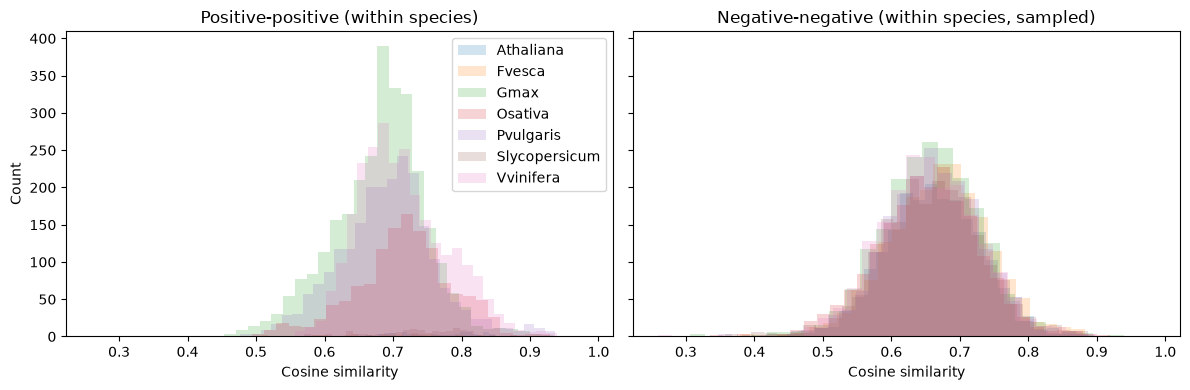

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
for ax, (df, title) in zip(axes, [
    (within_species_pos_sim, 'Positive-positive (within species)'),
    (baseline_neg_sim, 'Negative-negative (within species, sampled)'),
]):
    for species, grp in df.groupby('species'):
        ax.hist(grp['similarity'], bins=30, alpha=0.2, label=species)
    ax.set_title(title)
    ax.set_xlabel('Cosine similarity')

axes[0].set_ylabel('Count')
axes[0].legend()
plt.tight_layout()
plt.show()

### PCA

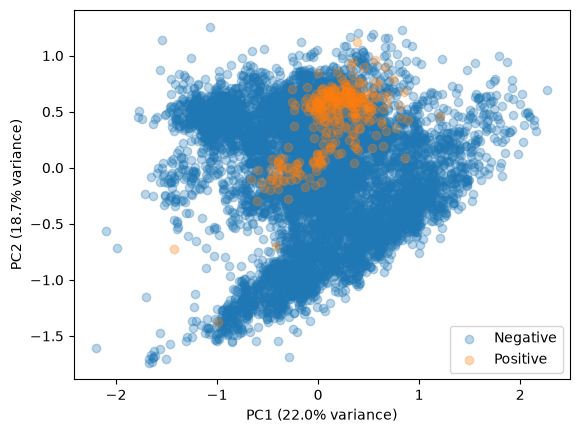

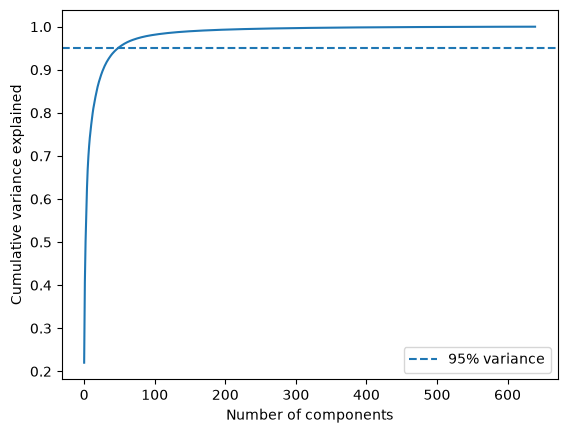

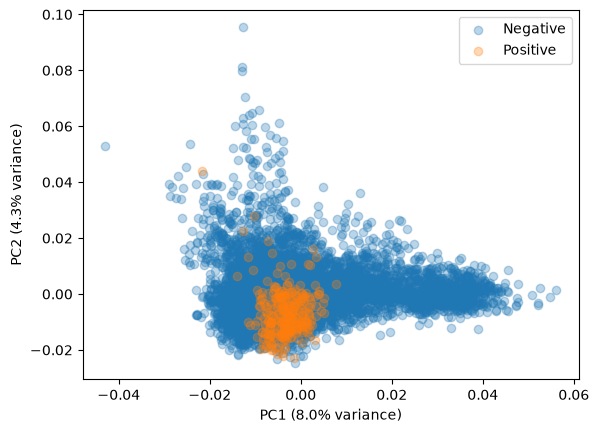

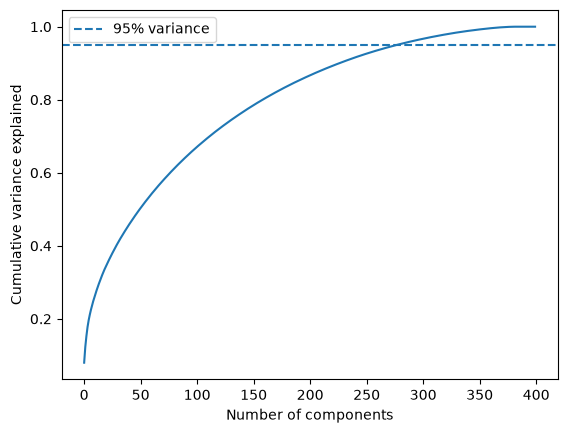

In [68]:
from sklearn.decomposition import PCA

def plot_pca(X, y):
    pca = PCA()

    pca_feats = pca.fit_transform(X)
    plt.scatter(pca_feats[y==0, 0], pca_feats[y==0, 1], label='Negative', alpha=0.3)
    plt.scatter(pca_feats[y==1, 0], pca_feats[y==1, 1], label='Positive', alpha=0.3)
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    plt.legend()
    plt.show()

    plt.plot(np.cumsum(pca.explained_variance_ratio_))
    plt.xlabel('Number of components')
    plt.ylabel('Cumulative variance explained')
    plt.axhline(0.95, linestyle='--', label='95% variance')
    plt.legend()
    plt.show()
  

plot_pca(X_deduped_esm, y_deduped)
plot_pca(X_deduped_kmer, y_deduped)

In [69]:
corr = X_deduped_esm.corr()
print(f"Max pairwise correlation: {corr.values[np.triu_indices_from(corr.values, k=1)].max()}")

Max pairwise correlation: 0.8517252016730817


In [70]:
corr = X_deduped_kmer.corr()
print(f"Max pairwise correlation: {corr.values[np.triu_indices_from(corr.values, k=1)].max()}")

Max pairwise correlation: 0.6899038911905531


In [71]:
def sim_btwn_bin(X, y):
    n_sequences = len(X)
    total_possible_pairs = n_sequences * (n_sequences - 1) / 2

    print(f"Total sequences: {n_sequences}")
    print(f"Total possible pairs: {total_possible_pairs}")

    # Base rate: P(different labels) if you pick any two sequences
    base_rate_diff_label = (y.sum() / len(y)) * ((len(y) - y.sum()) / len(y)) * 2
    print(f"Base rate P(different labels): {base_rate_diff_label:.4f}")

    # Compute similarity
    sim = cosine_similarity(X)

    # Look at high-similarity pairs
    threshold = 0.99
    high_sim_pairs = np.where((sim > threshold) & (sim < 1.0))

    # Count pairs with different labels
    n_diff_labels = 0
    for i, j in zip(high_sim_pairs[0], high_sim_pairs[1]):
        if y[i] != y[j]:
            n_diff_labels += 1

    n_high_sim_pairs = len(high_sim_pairs[0])
    
    if n_high_sim_pairs > 0:
        actual_rate_diff_label = n_diff_labels / n_high_sim_pairs
        ratio = actual_rate_diff_label / base_rate_diff_label
        print(f"High-similarity pairs: {n_high_sim_pairs}")
        print(f"With different labels: {n_diff_labels}")
        print(f"Actual rate P(different labels | high similarity): {actual_rate_diff_label:.4f}")
        print(f"Ratio (actual / base): {ratio:.2f}x")
    else:
        print(f"No high-similarity pairs found")

print('ESM:')
sim_btwn_bin(X_deduped_esm, y_deduped)

print('\nk-mer:')
sim_btwn_bin(X_deduped_kmer, y_deduped)

ESM:
Total sequences: 8894
Total possible pairs: 39547171.0
Base rate P(different labels): 0.0669
High-similarity pairs: 1231655
With different labels: 95670
Actual rate P(different labels | high similarity): 0.0777
Ratio (actual / base): 1.16x

k-mer:
Total sequences: 8894
Total possible pairs: 39547171.0
Base rate P(different labels): 0.0669
High-similarity pairs: 4482
With different labels: 0
Actual rate P(different labels | high similarity): 0.0000
Ratio (actual / base): 0.00x


In [ ]:
def check_feature_redundancy(X, name):
    X_df = pd.DataFrame(X)
    corr_matrix = X_df.corr()
    upper_triangle = np.triu_indices_from(corr_matrix.values, k=1)
    pairwise_correlations = corr_matrix.values[upper_triangle]

    print(f"{name}:")
    print(f"  Max pairwise correlation: {np.abs(pairwise_correlations).max():.3f}")
    print(f"  Mean pairwise correlation: {np.abs(pairwise_correlations).mean():.3f}")
    print(f"  Pairs with |corr| > 0.9: {(np.abs(pairwise_correlations) > 0.9).sum()}")
    print(f"  Pairs with |corr| > 0.8: {(np.abs(pairwise_correlations) > 0.8).sum()}")

check_feature_redundancy(X_deduped_esm, "ESM")
check_feature_redundancy(X_deduped_kmer, "k-mer")

ESM:
  Max pairwise correlation: 0.852
  Mean pairwise correlation: 0.212
  Pairs with |corr| > 0.9: 0
  Pairs with |corr| > 0.8: 25
k-mer:
  Max pairwise correlation: 0.690
  Mean pairwise correlation: 0.043
  Pairs with |corr| > 0.9: 0
  Pairs with |corr| > 0.8: 0


In [76]:
train_species_names = [
    'Athaliana_447_Araport11.protein_primaryTranscriptOnly', 
    'Fvesca_226_v1.1.protein_primaryTranscriptOnly',
    'Gmax_189_protein_primaryTranscriptOnly', 
    'Osativa_204_v7.0.protein_primaryTranscriptOnly', 
    'Pvulgaris_442_v2.1.protein_primaryTranscriptOnly', 
    'Vvinifera_457_v2.1.protein_primaryTranscriptOnly'
]

for train_sp in train_species_names:
    train_mask = groups_deduped == train_sp
    test_mask = groups_deduped == 'Slycopersicum_796_ITAG5.0.protein_primaryTranscriptOnly'
    X_train = X_deduped_esm.values[train_mask]
    X_test = X_deduped_esm.values[test_mask]
    sim_matrix = cosine_similarity(X_test, X_train)
    avg_sim = sim_matrix.mean()
    print(f"Slycopersicum vs {train_sp}: {avg_sim:.4f}")

print()
print(f"Slycopersicum positives: {(groups_deduped == 'Slycopersicum_796_ITAG5.0.protein_primaryTranscriptOnly').sum()} total, {(y_deduped[(groups_deduped == 'Slycopersicum_796_ITAG5.0.protein_primaryTranscriptOnly')]).sum()} positive")
print(f"Positive rate: {(y_deduped[(groups_deduped == 'Slycopersicum_796_ITAG5.0.protein_primaryTranscriptOnly')]).mean():.3%}")

print()
print("Compare to other species:")
for sp_full in train_species_names:
    mask = groups_deduped == sp_full
    n_total = mask.sum()
    n_pos = (y_deduped[mask]).sum()
    sp_short = sp_full.split('_')[0]
    print(f"{sp_short}: {n_pos}/{n_total} ({n_pos/n_total:.1%} positive)")

Slycopersicum vs Athaliana_447_Araport11.protein_primaryTranscriptOnly: 0.9554
Slycopersicum vs Fvesca_226_v1.1.protein_primaryTranscriptOnly: 0.9533
Slycopersicum vs Gmax_189_protein_primaryTranscriptOnly: 0.9540
Slycopersicum vs Osativa_204_v7.0.protein_primaryTranscriptOnly: 0.9475
Slycopersicum vs Pvulgaris_442_v2.1.protein_primaryTranscriptOnly: 0.9553
Slycopersicum vs Vvinifera_457_v2.1.protein_primaryTranscriptOnly: 0.9530

Slycopersicum positives: 958 total, 17 positive
Positive rate: 1.775%

Compare to other species:
Athaliana: 13/1015 (1.3% positive)
Fvesca: 10/924 (1.1% positive)
Gmax: 76/2194 (3.5% positive)
Osativa: 51/1434 (3.6% positive)
Pvulgaris: 68/1218 (5.6% positive)
Vvinifera: 73/1151 (6.3% positive)


In [77]:
# Are Slycopersicum's positives more similar to each other than to other species' positives?

sly_pos_idx = np.where((groups_deduped == 'Slycopersicum_796_ITAG5.0.protein_primaryTranscriptOnly') & (y_deduped == 1))[0]
other_pos_idx = np.where((groups_deduped != 'Slycopersicum_796_ITAG5.0.protein_primaryTranscriptOnly') & (y_deduped == 1))[0]

# Average similarity within Slycopersicum positives
sly_sim_matrix = cosine_similarity(X_deduped_esm.values[sly_pos_idx])
within_sly = sly_sim_matrix[np.triu_indices_from(sly_sim_matrix, k=1)].mean()

# Average similarity between Slycopersicum positives and other species' positives
cross_sim_matrix = cosine_similarity(X_deduped_esm.values[sly_pos_idx], X_deduped_esm.values[other_pos_idx])
between_sly_other = cross_sim_matrix.mean()

print(f"Within Slycopersicum positives: {within_sly:.4f}")
print(f"Between Slycopersicum and other species positives: {between_sly_other:.4f}")
print(f"Difference: {within_sly - between_sly_other:.4f}")

Within Slycopersicum positives: 0.9821
Between Slycopersicum and other species positives: 0.9793
Difference: 0.0028
